## API Connection Test

This initial test connects to the City of Chicago Traffic Crashes API and retrieves a small sample of crash records to verify that the endpoint is working correctly.

Bu ilk test, City of Chicago Traffic Crashes API'sine bağlanır ve API adresinin düzgün çalıştığını doğrulamak için küçük bir kaza kaydı örneği getirir.

In [1]:
import requests
# We can use the requests library to send HTTP requests from Python to an API.
# Python'dan bir API'ye HTTP isteği göndermek için requests kütüphanesini kullanabiliriz.

url = "https://data.cityofchicago.org/resource/85ca-t3if.json"
# We store the Chicago Traffic Crashes API endpoint in a variable called url.
# Chicago Traffic Crashes API adresini url isimli bir değişkende saklıyoruz.

params = {
    "$limit": 10000
}
# "$limit": 10000 tells the API to return up to 10,000 crash records instead of 10.
# "$limit": 10000, API'ye 10 kayıt yerine en fazla 10.000 kaza kaydı getirmesini söyler.


response = requests.get(url, params=params)
# Now we send a GET request to the API.
# Şimdi API'ye bir GET isteği gönderiyoruz.
# The API's response is stored in the response variable.
# API'den gelen cevap response değişkeninde saklanır.

data = response.json()
# The API returns the crash records in JSON format.
# API kaza kayıtlarını JSON formatında döndürür.
# response.json() converts the JSON response into Python objects that we can work with.
# response.json(), JSON cevabını Python'da çalışabileceğimiz nesnelere dönüştürür.

data[:2]

/Users/user/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


[{'crash_record_id': '000d36adce8b4b793e9d0c5cd09dfed2e71309972d34374e701513e9f7ad1023b624118756e4164d2851842868826342c334d8f5cae83376ae9a6e120cef2b2b',
  'crash_date': '2026-08-20T13:29:00.000',
  'posted_speed_limit': '30',
  'traffic_control_device': 'NO CONTROLS',
  'device_condition': 'NO CONTROLS',
  'weather_condition': 'CLEAR',
  'lighting_condition': 'DAYLIGHT',
  'first_crash_type': 'PARKED MOTOR VEHICLE',
  'trafficway_type': 'ONE-WAY',
  'alignment': 'STRAIGHT AND LEVEL',
  'roadway_surface_cond': 'DRY',
  'road_defect': 'NO DEFECTS',
  'report_type': 'ON SCENE',
  'crash_type': 'NO INJURY / DRIVE AWAY',
  'damage': 'OVER $1,500',
  'date_police_notified': '2026-08-20T15:54:00.000',
  'prim_contributory_cause': 'IMPROPER BACKING',
  'sec_contributory_cause': 'UNABLE TO DETERMINE',
  'street_no': '1398',
  'street_direction': 'E',
  'street_name': '53RD ST',
  'beat_of_occurrence': '234',
  'num_units': '2',
  'crash_month': '8',
  'most_severe_injury': 'NO INDICATION OF INJ

In [2]:
# However, this JSON-style output is difficult to analyze directly.
# Fakat bu JSON tarzındaki çıktıyı doğrudan analiz etmek oldukça zor.

# For Data Science analysis, a table with rows and columns will be much easier to work with.
# Data Science analizi için satır ve sütunlardan oluşan bir tabloyla çalışmak çok daha kolay olacak.

import pandas as pd

df = pd.DataFrame(data)
# pd.DataFrame(data) converts our list of crash records into a table with rows and columns.
# pd.DataFrame(data), kaza kayıtlarımızın bulunduğu listeyi satır ve sütunlardan oluşan bir tabloya dönüştürür.

df.head()
# df.head() displays the first five rows of the DataFrame by default.
# df.head(), DataFrame'in varsayılan olarak ilk beş satırını gösterir.

,crash_record_id,crash_date,posted_speed_limit,traffic_control_device,device_condition,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,...,intersection_related_i,crash_date_est_i,private_property_i,photos_taken_i,lane_cnt,statements_taken_i,dooring_i,work_zone_i,work_zone_type,workers_present_i
0,000d36adce8b4b793e9d0c5cd09dfed2e71309972d3437...,2026-08-20T13:29:00.000,30,NO CONTROLS,NO CONTROLS,CLEAR,DAYLIGHT,PARKED MOTOR VEHICLE,ONE-WAY,STRAIGHT AND LEVEL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,419e0f4348b4274d902d84bd7aa58f5fa9c10820b77abc...,2026-05-19T23:15:00.000,45,STOP SIGN/FLASHER,FUNCTIONING IMPROPERLY,CLEAR,DARKNESS,TURNING,DIVIDED - W/MEDIAN (NOT RAISED),STRAIGHT AND LEVEL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1471094d2f2a497653584d887ed73cddcdfaa35fd02b20...,2026-05-20T07:51:00.000,30,STOP SIGN/FLASHER,FUNCTIONING PROPERLY,CLEAR,DAYLIGHT,PEDESTRIAN,FOUR WAY,STRAIGHT AND LEVEL,...,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1c99690e19bd557cc6ad0674668dc492ab979c4e63a279...,2026-05-20T02:00:00.000,30,UNKNOWN,UNKNOWN,CLEAR,"DARKNESS, LIGHTED ROAD",FIXED OBJECT,NOT DIVIDED,STRAIGHT AND LEVEL,...,NaN,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,401b13002f631a3faa4af328d3896d70547210e3cfc218...,2026-05-20T07:50:00.000,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,DAYLIGHT,SIDESWIPE SAME DIRECTION,FOUR WAY,STRAIGHT AND LEVEL,...,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.shape
# df.shape returns the number of rows and columns in the DataFrame as (rows, columns).
# df.shape, DataFrame'deki satır ve sütun sayısını (satır, sütun) şeklinde verir.

(10000, 50)

In [4]:
df.columns
# df.columns returns the names of all columns in the DataFrame.
# df.columns, DataFrame içerisindeki bütün sütunların isimlerini verir.
# This helps us inspect the available variables before selecting the columns needed for the analysis.
# Bu, analiz için gerekli sütunları seçmeden önce mevcut değişkenleri incelememize yardımcı olur.

Index(['crash_record_id', 'crash_date', 'posted_speed_limit',
       'traffic_control_device', 'device_condition', 'weather_condition',
       'lighting_condition', 'first_crash_type', 'trafficway_type',
       'alignment', 'roadway_surface_cond', 'road_defect', 'report_type',
       'crash_type', 'damage', 'date_police_notified',
       'prim_contributory_cause', 'sec_contributory_cause', 'street_no',
       'street_direction', 'street_name', 'beat_of_occurrence', 'num_units',
       'crash_month', 'most_severe_injury', 'injuries_total', 'injuries_fatal',
       'injuries_incapacitating', 'injuries_non_incapacitating',
       'injuries_reported_not_evident', 'injuries_no_indication',
       'injuries_unknown', 'crash_hour', 'crash_day_of_week',
       'idot_control_no', 'latitude', 'longitude', 'location',
       ':@computed_region_rpca_8um6', 'hit_and_run_i',
       'intersection_related_i', 'crash_date_est_i', 'private_property_i',
       'photos_taken_i', 'lane_cnt', 'statements_ta

## Initial Data Inspection

Before preparing the data for analysis, we inspect the dataset structure, data types, and missing values.

Analize hazırlamadan önce veri setinin yapısını, veri tiplerini ve eksik değerlerini inceliyoruz.

In [5]:
df.info()
# df.info() provides a summary of the structure of the DataFrame.
# df.info(), DataFrame'in yapısının özetini verir.

# df.info() shows the number of rows, column names, non-null counts, and data types.
# df.info(), satır sayısını, sütun isimlerini, boş olmayan değer sayılarını ve veri tiplerini gösterir.

# The Dtype section is especially important because API data may initially arrive with unexpected data types.
# Dtype bölümü özellikle önemli çünkü API'den gelen veriler başlangıçta beklemediğimiz veri tipleriyle gelebilir.
# 'posted_speed_limit': '25'
# For example, '25' is enclosed in quotation marks, so Python may initially interpret it as a string rather than a number.
# Örneğin, '25' tırnak içinde olduğu için Python bunu başlangıçta sayı yerine string olarak algılamış olabilir.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   crash_record_id                10000 non-null  object
 1   crash_date                     10000 non-null  object
 2   posted_speed_limit             10000 non-null  object
 3   traffic_control_device         10000 non-null  object
 4   device_condition               10000 non-null  object
 5   weather_condition              10000 non-null  object
 6   lighting_condition             10000 non-null  object
 7   first_crash_type               10000 non-null  object
 8   trafficway_type                10000 non-null  object
 9   alignment                      10000 non-null  object
 10  roadway_surface_cond           10000 non-null  object
 11  road_defect                    10000 non-null  object
 12  report_type                    9657 non-null   object
 13  cr

In [6]:
df.isnull().sum()
# df.isnull() checks every value in the DataFrame and identifies whether it is missing.
# df.isnull(), DataFrame'deki her değeri kontrol eder ve eksik olup olmadığını belirler.

# df.isnull().sum() counts the number of missing values in each column.
# df.isnull().sum(), her sütundaki eksik değerlerin sayısını hesaplar.

crash_record_id                     0
crash_date                          0
posted_speed_limit                  0
traffic_control_device              0
device_condition                    0
weather_condition                   0
lighting_condition                  0
first_crash_type                    0
trafficway_type                     0
alignment                           0
roadway_surface_cond                0
road_defect                         0
report_type                       343
crash_type                          0
damage                              0
date_police_notified                0
prim_contributory_cause             0
sec_contributory_cause              0
street_no                           0
street_direction                    0
street_name                         0
beat_of_occurrence                  0
num_units                           0
crash_month                         0
most_severe_injury                 75
injuries_total                     75
injuries_fat

report_type = 343 means 343 out of 10,000 crash records have no value in the report_type column.
report_type = 343, 10.000 kaza kaydının 343 tanesinde report_type değerinin eksik olduğu anlamına gelir.

dooring_i = 9971 means 9,971 out of 10,000 records have no value in the dooring_i column.
dooring_i = 9971, 10.000 kaydın 9.971 tanesinde dooring_i değerinin eksik olduğu anlamına gelir.

However, we should not immediately conclude that `dooring_i` is a poor-quality or unusable column.

Ancak burada hemen `dooring_i` sütununun düşük kaliteli veya kullanılamaz bir sütun olduğu sonucuna varamayız.

For indicator columns such as dooring_i, a missing value may have a special meaning rather than simply representing bad or unavailable data.
dooring_i gibi indicator sütunlarında missing value, sadece kötü veya elde edilemeyen veri anlamına gelmek yerine özel bir anlam taşıyabilir.

<!-- report_type = 343 means 343 out of 10,000 crash records have no value in the report_type column.
report_type = 343, 10.000 kaza kaydının 343 tanesinde report_type değerinin eksik olduğu anlamına gelir.

dooring_i = 9971 means 9,971 out of 10,000 records have no value in the dooring_i column.
dooring_i = 9971, 10.000 kaydın 9.971 tanesinde dooring_i değerinin eksik olduğu anlamına gelir.

Ama burada hemen dooring_i kötü bir sütundur diyemeyiz.

For indicator columns such as dooring_i, a missing value may have a special meaning rather than simply representing bad or unavailable data.
dooring_i gibi indicator sütunlarında missing value, sadece kötü veya elde edilemeyen veri anlamına gelmek yerine özel bir anlam taşıyabilir. -->

In [7]:
(df.isnull().sum() / len(df)) * 100

# df.isnull() checks every value in df and identifies missing values.
# df.isnull(), df içerisindeki her değeri kontrol eder ve missing value'ları belirler.

# df.isnull().sum() counts the missing values in each column.
# df.isnull().sum(), her sütundaki missing value sayısını hesaplar.

# len(df) returns the total number of rows in df, which is currently 10,000.
# len(df), df içerisindeki toplam satır sayısını verir; şu anda bu sayı 10.000.

# df.isnull().sum() / len(df) calculates the proportion of missing values in each column.
# df.isnull().sum() / len(df), her sütundaki missing value oranını hesaplar.

# Multiplying by 100 converts that proportion into a percentage.
# 100 ile çarpmak bu oranı yüzdeye dönüştürür.

crash_record_id                   0.00
crash_date                        0.00
posted_speed_limit                0.00
traffic_control_device            0.00
device_condition                  0.00
weather_condition                 0.00
lighting_condition                0.00
first_crash_type                  0.00
trafficway_type                   0.00
alignment                         0.00
roadway_surface_cond              0.00
road_defect                       0.00
report_type                       3.43
crash_type                        0.00
damage                            0.00
date_police_notified              0.00
prim_contributory_cause           0.00
sec_contributory_cause            0.00
street_no                         0.00
street_direction                  0.00
street_name                       0.00
beat_of_occurrence                0.00
num_units                         0.00
crash_month                       0.00
most_severe_injury                0.75
injuries_total           

## Select Relevant Columns

## İlgili Sütunları Seçme

Feature selection means choosing the variables that are relevant to the questions we want to answer.

Feature selection, cevaplamak istediğimiz sorularla ilgili değişkenleri seçmek anlamına gelir.

The main research question guiding our variable selection is:

Değişken seçimimize yön veren ana araştırma sorusu şudur:

**What factors are associated with severe traffic crashes in Chicago?**

**Chicago'daki ciddi trafik kazalarıyla hangi faktörler ilişkilidir?**

## Select Relevant Columns

The analysis focuses on variables related to crash conditions, contributing factors, injury severity, time, and location.

Analiz; kaza koşulları, katkıda bulunan faktörler, yaralanma şiddeti, zaman ve konum ile ilgili değişkenlere odaklanmaktadır.

The selected variables will be used to investigate the factors associated with severe traffic crashes in Chicago.

Seçilen değişkenler, Chicago'daki ciddi trafik kazalarıyla ilişkili faktörleri incelemek için kullanılacaktır.

In [8]:
selected_columns = [
    "crash_date",
    "posted_speed_limit",
    "traffic_control_device",
    "weather_condition",
    "lighting_condition",
    "first_crash_type",
    "trafficway_type",
    "roadway_surface_cond",
    "road_defect",
    "prim_contributory_cause",
    "crash_type",
    "most_severe_injury",
    "injuries_total",
    "injuries_fatal",
    "injuries_incapacitating",
    "crash_hour",
    "crash_day_of_week",
    "latitude",
    "longitude"
]

# selected_columns is a Python list containing the names of the columns we want to use in our analysis.
# selected_columns, analizimizde kullanmak istediğimiz sütunların isimlerini içeren bir Python listesidir.

df_selected = df[selected_columns].copy()

# df[selected_columns] selects only the columns listed inside selected_columns from df.
# df[selected_columns], df içerisinden sadece selected_columns listesinde bulunan sütunları seçer.

# df_selected = ... stores this smaller DataFrame in a new variable called df_selected.
# df_selected = ..., oluşturduğumuz daha küçük DataFrame'i df_selected isimli yeni bir değişkende saklar.
# .copy() creates an independent copy of the selected data for further analysis and cleaning.
# .copy(), seçilen verilerin sonraki analiz ve temizleme işlemleri için ayrı bir kopyasını oluşturur.


### Why These Columns Were Selected

The original `df` remains unchanged with 10,000 rows and 50 columns.

Orijinal `df`, 10.000 satır ve 50 sütun ile değişmeden kalır.

A new DataFrame called `df_selected` contains the 19 variables selected for the analysis.

`df_selected` adlı yeni DataFrame, analiz için seçilen 19 değişkeni içerir.

Weather, lighting, and road surface variables help us investigate environmental conditions.

Hava durumu, ışık ve yol yüzeyi değişkenleri çevresel koşulları incelememize yardımcı olur.

Speed limit, traffic controls, road type, and road defects help us investigate roadway conditions.

Hız limiti, trafik kontrolleri, yol tipi ve yol kusurları yol koşullarını incelememize yardımcı olur.

Primary contributory cause helps us investigate recorded contributing factors such as driver behavior.

Birincil katkı nedeni, sürücü davranışı gibi kaydedilmiş katkı faktörlerini incelememize yardımcı olur.

Injury-related variables help us measure crash severity.

Yaralanmayla ilgili değişkenler kaza şiddetini ölçmemize yardımcı olur.

Crash hour, day, and date allow us to investigate temporal patterns.

Kaza saati, günü ve tarihi zamana bağlı örüntüleri incelememizi sağlar.

Latitude and longitude allow us to investigate geographic patterns later in the analysis.

Latitude ve longitude, analizin ilerleyen bölümlerinde coğrafi örüntüleri incelememizi sağlar.

In [9]:
df_selected.shape

# df_selected.shape returns the number of rows and columns in our newly selected DataFrame.
# df_selected.shape, yeni oluşturduğumuz seçilmiş DataFrame'in satır ve sütun sayısını verir.

# This confirms that we kept all 10,000 records while reducing the dataset from 50 columns to 19 selected columns.
# Bu, veri setini 50 sütundan seçilen 19 sütuna indirirken 10.000 kaydın tamamını koruduğumuzu doğrular.

(10000, 19)

## Check Data Types

Before cleaning and analyzing the selected variables, we check their current data types to identify columns that may require conversion.

Seçilen değişkenleri temizlemeden ve analiz etmeden önce, dönüştürülmesi gerekebilecek sütunları belirlemek için mevcut veri tiplerini kontrol ediyoruz.

In [10]:
df_selected.dtypes

# df_selected.dtypes returns the data type of every column in df_selected.
# df_selected.dtypes, df_selected içerisindeki her sütunun veri tipini gösterir.

crash_date                 object
posted_speed_limit         object
traffic_control_device     object
weather_condition          object
lighting_condition         object
first_crash_type           object
trafficway_type            object
roadway_surface_cond       object
road_defect                object
prim_contributory_cause    object
crash_type                 object
most_severe_injury         object
injuries_total             object
injuries_fatal             object
injuries_incapacitating    object
crash_hour                 object
crash_day_of_week          object
latitude                   object
longitude                  object
dtype: object

### Data Type Interpretation

All 19 selected variables are currently stored as `object`, including variables that represent dates and numeric values.

Seçilen 19 değişkenin tamamı şu anda `object` olarak saklanıyor; buna tarih ve sayısal değerleri temsil eden değişkenler de dahil.

Before analysis, these variables should be converted to appropriate data types where necessary.

Analizden önce, gerekli olan değişkenler uygun veri tiplerine dönüştürülmelidir.

### Data Type Interpretation

Numeric variables should generally use numeric data types, date variables should use datetime, and categorical or text variables can remain as object/string types.

Sayısal değişkenlerin genel olarak sayısal veri tiplerinde, tarih değişkenlerinin datetime tipinde, kategorik veya metinsel değişkenlerin ise object/string tipinde olması beklenir.

The `df_selected.dtypes` output shows that all 19 selected columns are currently stored as `object`, including variables that represent dates and numeric values.

`df_selected.dtypes` çıktısı, tarih ve sayısal değerleri temsil eden değişkenler dahil olmak üzere seçilen 19 sütunun tamamının şu anda `object` olarak saklandığını gösterir.

Categorical variables such as `weather_condition` and `lighting_condition` can remain as categorical/text data because their values represent categories such as `CLEAR`, `RAIN`, or `DAYLIGHT`.

`weather_condition` ve `lighting_condition` gibi kategorik değişkenler, `CLEAR`, `RAIN` veya `DAYLIGHT` gibi kategorileri temsil ettikleri için kategorik/metinsel veri olarak kalabilir.

However, variables such as `posted_speed_limit`, injury counts, crash hour, crash day, latitude, and longitude should be numeric so they can be analyzed correctly.

Ancak `posted_speed_limit`, yaralanma sayıları, kaza saati, kaza günü, latitude ve longitude gibi değişkenler doğru şekilde analiz edilebilmeleri için sayısal veri tipinde olmalıdır.

The `crash_date` variable should be converted from `object` to datetime so that dates can be filtered, sorted, and analyzed correctly.

`crash_date` değişkeni ise tarihlerin doğru şekilde filtrelenebilmesi, sıralanabilmesi ve analiz edilebilmesi için `object` tipinden datetime tipine dönüştürülmelidir.

We will convert the necessary variables to appropriate data types before continuing with the analysis.

Analize devam etmeden önce gerekli değişkenleri uygun veri tiplerine dönüştüreceğiz.

### Convert `crash_date` to Datetime

We will begin by converting `crash_date` from `object` to a datetime data type.

İlk olarak `crash_date` değişkenini `object` tipinden datetime veri tipine dönüştüreceğiz.

Veri tipleri kabaca nasıl olmalı?
Column	Current	Desired
crash_date	object	datetime
posted_speed_limit	object	numeric
weather_condition	object	categorical/text
lighting_condition	object	categorical/text
roadway_surface_cond	object	categorical/text
injuries_total	object	numeric
injuries_fatal	object	numeric
injuries_incapacitating	object	numeric
crash_hour	object	numeric
crash_day_of_week	object	numeric
latitude	object	numeric
longitude	object	numeric

Şimdi hepsini bir anda değiştirmeyeceğiz. İlk olarak crash_date ile başlayalım.

Convert crash_date to datetime
crash_date sütununu datetime'a dönüştürme

In [11]:
df_selected["crash_date"] = pd.to_datetime(df_selected["crash_date"], errors="coerce")

# df_selected["crash_date"] selects the crash_date column from df_selected.
# df_selected["crash_date"], df_selected içerisindeki crash_date sütununu seçer.

# pd.to_datetime() converts values into Pandas datetime values.
# pd.to_datetime(), değerleri Pandas'ın tarih-saat veri tipine dönüştürür.

# errors="coerce" converts values that cannot be interpreted as valid dates into NaT instead of stopping the program with an error.
# errors="coerce", geçerli bir tarihe dönüştürülemeyen değerlerde programı hata vererek durdurmak yerine bunları NaT yapar.

# NaT (Not a Time) represents a missing datetime value in Pandas, similar to NaN for numeric data.
# NaT (Not a Time), Pandas'ta eksik bir datetime değerini temsil eder ve sayısal verilerdeki NaN'e benzer.

# The assignment with = replaces the old crash_date column with the converted version.
# = ile yaptığımız atama, eski crash_date sütununu dönüştürülmüş haliyle değiştirir.

In [12]:
df_selected["crash_date"].dtype

# df_selected["crash_date"].dtype returns the current data type of the crash_date column.
# df_selected["crash_date"].dtype, crash_date sütununun mevcut veri tipini gösterir.

# The output dtype('<M8[ns]') represents datetime64[ns], confirming that the conversion was successful.
# dtype('<M8[ns]') çıktısı datetime64[ns] veri tipini temsil eder ve dönüşümün başarılı olduğunu doğrular.

dtype('<M8[ns]')

### Convert Numeric Columns

The `crash_date` conversion is complete, but several variables that represent numeric values are still stored as `object`.

`crash_date` dönüşümü tamamlandı, ancak sayısal değerleri temsil eden bazı değişkenler hâlâ `object` olarak saklanıyor.

These columns should be converted to numeric data types before performing calculations and statistical analysis.

Hesaplamalar ve istatistiksel analizler yapılmadan önce bu sütunların sayısal veri tiplerine dönüştürülmesi gerekir.

In [13]:
numeric_columns = [
    "posted_speed_limit",
    "injuries_total",
    "injuries_fatal",
    "injuries_incapacitating",
    "crash_hour",
    "crash_day_of_week",
    "latitude",
    "longitude"
]

# numeric_columns is a Python list containing the columns that should contain numerical values.
# numeric_columns, sayısal değerler içermesi gereken sütunların isimlerini tutan bir Python listesidir.

In [14]:
for column in numeric_columns:
    df_selected[column] = pd.to_numeric(
        df_selected[column],
        errors="coerce"
    )

df_selected[numeric_columns].dtypes

# for column in numeric_columns: goes through the columns in numeric_columns one by one.
# for column in numeric_columns:, numeric_columns listesindeki sütunları tek tek dolaşır.

# df_selected[column] selects the column currently being processed by the loop.
# df_selected[column], döngünün o anda işlem yaptığı sütunu seçer.

# pd.to_numeric() converts the values in the selected column to numeric values.
# pd.to_numeric(), seçilen sütundaki değerleri sayısal değerlere dönüştürür.

# errors="coerce" converts values that cannot be interpreted as numbers into NaN.
# errors="coerce", sayıya dönüştürülemeyen değerleri NaN'e dönüştürür.

# df_selected[numeric_columns].dtypes displays the data types of the converted columns.
# df_selected[numeric_columns].dtypes, dönüştürülen sütunların veri tiplerini gösterir.

posted_speed_limit           int64
injuries_total             float64
injuries_fatal             float64
injuries_incapacitating    float64
crash_hour                   int64
crash_day_of_week            int64
latitude                   float64
longitude                  float64
dtype: object

### Numeric Conversion Result

The numeric conversion was successful, and the selected columns are now stored as `int64` or `float64` rather than `object`.

Sayısal dönüşüm başarılı oldu ve seçilen sütunlar artık `object` yerine `int64` veya `float64` olarak saklanıyor.

For example, text representations of numbers such as `"25"` and `"41.8781"` can now be treated as the numeric values `25` and `41.8781`.

Örneğin `"25"` ve `"41.8781"` gibi metin biçimindeki sayılar artık `25` ve `41.8781` sayısal değerleri olarak işlenebilir.

Because `errors="coerce"` was used, any values that could not be converted to numbers were replaced with `NaN`.

`errors="coerce"` kullandığımız için sayıya dönüştürülemeyen değerler `NaN` ile değiştirildi.

Therefore, the next step is to check whether the conversion introduced any new missing values.

Bu nedenle bir sonraki adım, dönüşümün yeni eksik değerler oluşturup oluşturmadığını kontrol etmektir.

### Check Missing Values After Conversion

After converting the numeric columns, we need to check whether any values became missing during the conversion.

Sayısal sütunları dönüştürdükten sonra, dönüşüm sırasında herhangi bir değerin eksik değere dönüşüp dönüşmediğini kontrol etmemiz gerekir.

In [15]:
df_selected.isnull().sum()

# df_selected.isnull() checks every value in df_selected and identifies missing values.
# df_selected.isnull(), df_selected içerisindeki her değeri kontrol eder ve eksik değerleri belirler.

# .sum() counts the number of missing values in each column.
# .sum(), her sütundaki eksik değerlerin sayısını hesaplar.

crash_date                    0
posted_speed_limit            0
traffic_control_device        0
weather_condition             0
lighting_condition            0
first_crash_type              0
trafficway_type               0
roadway_surface_cond          0
road_defect                   0
prim_contributory_cause       0
crash_type                    0
most_severe_injury           75
injuries_total               75
injuries_fatal               75
injuries_incapacitating      75
crash_hour                    0
crash_day_of_week             0
latitude                   2001
longitude                  2001
dtype: int64

In [16]:
df_selected[
    df_selected["injuries_total"].isnull()
][
    [
        "most_severe_injury",
        "injuries_total",
        "injuries_fatal",
        "injuries_incapacitating"
    ]
].head(10)

# df_selected["injuries_total"].isnull() identifies the rows where injuries_total is missing.
# df_selected["injuries_total"].isnull(), injuries_total değerinin eksik olduğu satırları belirler.

# df_selected[...] keeps only those rows.
# df_selected[...], sadece bu satırları seçer.

# The second pair of brackets selects only the four injury-related columns we want to inspect.
# İkinci köşeli parantez grubu, incelemek istediğimiz sadece dört yaralanma sütununu seçer.

# .head(10) displays the first 10 matching rows.
# .head(10), bu koşula uyan ilk 10 satırı gösterir.

,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating
46,NaN,NaN,NaN,NaN
82,NaN,NaN,NaN,NaN
100,NaN,NaN,NaN,NaN
228,NaN,NaN,NaN,NaN
281,NaN,NaN,NaN,NaN
346,NaN,NaN,NaN,NaN
525,NaN,NaN,NaN,NaN
578,NaN,NaN,NaN,NaN
635,NaN,NaN,NaN,NaN
731,NaN,NaN,NaN,NaN


In [17]:
df_selected[
    df_selected["injuries_total"].isnull()
][
    [
        "most_severe_injury",
        "injuries_total",
        "injuries_fatal",
        "injuries_incapacitating"
    ]
].isnull().sum()

# The first part selects all rows where injuries_total is missing.
# İlk kısım, injuries_total değerinin eksik olduğu bütün satırları seçer.

# Then we keep only the four injury-related columns.
# Daha sonra sadece yaralanmayla ilgili dört sütunu tutarız.

# .isnull() checks whether each value is missing.
# .isnull(), her değerin eksik olup olmadığını kontrol eder.

# .sum() counts the missing values in each of those four columns.
# .sum(), bu dört sütunun her birindeki eksik değerleri sayar.

most_severe_injury         75
injuries_total             75
injuries_fatal             75
injuries_incapacitating    75
dtype: int64

### Inspect Categorical Variables

Before cleaning the categorical variables, we should inspect their unique values and frequencies to identify categories such as `UNKNOWN`, unusual values, or categories that may require special handling.

Kategorik değişkenleri temizlemeden önce, `UNKNOWN` gibi kategorileri, olağandışı değerleri veya özel işlem gerektirebilecek kategorileri belirlemek için benzersiz değerlerini ve görülme sıklıklarını incelemeliyiz.

In [18]:
df_selected["weather_condition"].value_counts()

# df_selected["weather_condition"] selects the weather_condition column.
# df_selected["weather_condition"], weather_condition sütununu seçer.

# .value_counts() counts how many times each unique weather condition appears.
# .value_counts(), her farklı hava durumu değerinin kaç kez bulunduğunu sayar.

weather_condition
CLEAR                     7788
RAIN                       863
UNKNOWN                    578
CLOUDY/OVERCAST            343
SNOW                       314
FREEZING RAIN/DRIZZLE       37
OTHER                       32
FOG/SMOKE/HAZE              16
BLOWING SNOW                15
SLEET/HAIL                  10
SEVERE CROSS WIND GATE       4
Name: count, dtype: int64

Bu Data Science'ta önemli bir nokta:

NaN        → technically missing
UNKNOWN    → value exists, but information is unknown

In [19]:
df_selected["lighting_condition"].value_counts()

# df_selected["lighting_condition"] selects the lighting_condition column.
# df_selected["lighting_condition"], lighting_condition sütununu seçer.

# .value_counts() counts how many crashes belong to each lighting category.
# .value_counts(), her aydınlatma kategorisinde kaç kaza bulunduğunu hesaplar.

lighting_condition
DAYLIGHT                  6400
DARKNESS, LIGHTED ROAD    2231
DARKNESS                   454
UNKNOWN                    454
DUSK                       277
DAWN                       184
Name: count, dtype: int64

In [20]:
df_selected["roadway_surface_cond"].value_counts()

# df_selected["roadway_surface_cond"] selects the road surface condition column.
# df_selected["roadway_surface_cond"], yol yüzeyi durumu sütununu seçer.

# .value_counts() shows each road surface category and the number of crashes in that category.
# .value_counts(), her yol yüzeyi kategorisini ve o kategorideki kaza sayısını gösterir.

roadway_surface_cond
DRY                7279
WET                1343
UNKNOWN             917
SNOW OR SLUSH       342
ICE                  87
OTHER                29
SAND, MUD, DIRT       3
Name: count, dtype: int64

In [21]:
df_selected["most_severe_injury"].value_counts(dropna=False)

# df_selected["most_severe_injury"] selects the most_severe_injury column.
# df_selected["most_severe_injury"], most_severe_injury sütununu seçer.

# .value_counts() counts how many crashes belong to each injury-severity category.
# .value_counts(), her yaralanma şiddeti kategorisinde kaç kaza olduğunu sayar.

# dropna=False tells Pandas to include missing (NaN) values in the result instead of hiding them.
# dropna=False, Pandas'a missing (NaN) değerleri sonuçtan çıkarmak yerine göstermesini söyler.

# Bu sefer özellikle dropna=False kullanıyoruz çünkü daha önce bulduğumuz 75 missing value'u da aynı tabloda görmek istiyoruz.

most_severe_injury
NO INDICATION OF INJURY     8529
NONINCAPACITATING INJURY     795
REPORTED, NOT EVIDENT        428
INCAPACITATING INJURY        163
NaN                           75
FATAL                         10
Name: count, dtype: int64

In [22]:
df_selected["posted_speed_limit"].value_counts().sort_index()

# df_selected["posted_speed_limit"] selects the speed-limit column.
# df_selected["posted_speed_limit"], hız limiti sütununu seçer.

# .value_counts() counts how many crashes have each recorded speed limit.
# .value_counts(), her kayıtlı hız limitinde kaç kaza olduğunu sayar.

# .sort_index() sorts those speed-limit values numerically from smallest to largest.
# .sort_index(), hız limiti değerlerini sayısal olarak küçükten büyüğe sıralar.

posted_speed_limit
0       63
3        2
5       53
10     343
15     521
20     647
22       1
24       1
25     723
30    6749
35     606
40      98
45     123
50       7
55      59
60       4
Name: count, dtype: int64

In [23]:
df_selected["crash_date"].min()

# df_selected["crash_date"] selects the crash_date column.
# df_selected["crash_date"], crash_date sütununu seçer.

# .min() returns the earliest date in that column.
# .min(), bu sütundaki en eski tarihi verir.

Timestamp('2015-09-04 13:00:00')

In [24]:
df_selected["crash_date"].max()

# .max() returns the latest date in the crash_date column.
# .max(), crash_date sütunundaki en yeni tarihi verir.

Timestamp('2026-08-21 00:00:00')

In [25]:
df_selected["crash_date"].dt.year.value_counts().sort_index()

# df_selected["crash_date"].dt.year extracts the year from every crash date.
# df_selected["crash_date"].dt.year, her kaza tarihinden yıl bilgisini çıkarır.

# For example:
# Örneğin:

# 2023-08-15 → 2023
# 2024-02-10 → 2024

# .value_counts() counts how many records we currently have for each year.
# .value_counts(), şu anda her yıl için kaç kayıt bulunduğunu sayar.

# .sort_index() sorts the years from earliest to latest.
# .sort_index(), yılları eskiden yeniye doğru sıralar.

crash_date
2015      66
2016     319
2017     626
2018     875
2019     827
2020     940
2021    1741
2022    1562
2023     790
2024     950
2025    1001
2026     303
Name: count, dtype: int64

### Filter the API Data to the Project Period

The initial API sample includes crash records outside the target period of this project. To focus the analysis on 2021–2025, the API request will be filtered to include crashes from January 1, 2021 through December 31, 2025.

İlk API örneklemi, projenin hedef tarih aralığı dışında kalan kaza kayıtlarını da içeriyor. Analizi 2021–2025 dönemine odaklamak için API isteği 1 Ocak 2021 ile 31 Aralık 2025 arasındaki kazaları içerecek şekilde filtrelenecek.

In [ ]:
url = "https://data.cityofchicago.org/resource/85ca-t3if.json"

response = requests.get(url, params=params)

# requests.get() sends our request to the Chicago API.
# requests.get(), isteğimizi Chicago API'sine gönderir.

data_test = response.json()

# response.json() converts the API response into Python data.
# response.json(), API'den gelen cevabı Python verisine dönüştürür.

df_test = pd.DataFrame(data_test)

# pd.DataFrame(data_test) converts the test data into a Pandas DataFrame.
# pd.DataFrame(data_test), test verisini Pandas DataFrame'e dönüştürür.

df_test["crash_date"].head()

# df_test["crash_date"].head() displays the first five crash dates returned by our test API request.
# df_test["crash_date"].head(), test API isteğimizden gelen ilk beş kaza tarihini gösterir.

0       2020-07-28T21:37:00.000
1       2020-08-12T18:49:00.000
2       2020-08-09T01:55:00.000
3       2020-07-27T09:30:00.000
4       2020-08-10T16:30:00.000
                 ...           
9995    2024-02-24T19:30:00.000
9996    2019-12-24T11:35:00.000
9997    2018-07-04T13:50:00.000
9998    2019-02-09T19:10:00.000
9999    2022-11-13T12:55:00.000
Name: crash_date, Length: 10000, dtype: object

### Count Records in the Selected Period

Before retrieving the complete dataset, we check how many crash records are available for the 2021–2025 project period.

Tam veri setini almadan önce, 2021–2025 proje dönemi için kaç kaza kaydı bulunduğunu kontrol ediyoruz.

In [27]:
count_params = {
    "$select": "count(*)",
    "$where": "crash_date >= '2021-01-01T00:00:00' AND crash_date < '2026-01-01T00:00:00'"
}

# count_params stores the parameters for a separate API request that will count the records.
# count_params, kayıtları saymak için yapacağımız ayrı API isteğinin parametrelerini tutar.
# $select tells the API what information we want returned.
# $select, API'ye hangi bilgiyi döndürmesini istediğimizi söyler.
# count(*) means “count all rows that satisfy our condition.”
# count(*), “koşulumuzu sağlayan bütün satırları say” anlamına gelir.

count_response = requests.get(url, params=count_params)

# requests.get() sends this counting request to the API.
# requests.get(), bu sayma isteğini API'ye gönderir.

count_data = count_response.json()

# response.json() converts the API response into Python data.
# response.json(), API cevabını Python verisine dönüştürür.

count_data

# count_data displays the result returned by the API.
# count_data, API'nin döndürdüğü sonucu gösterir.

[{'count': '549108'}]

### Count Records in the Selected Period

Before retrieving the complete dataset, we check how many crash records are available for the 2021–2025 project period.

Tam veri setini almadan önce, 2021–2025 proje dönemi için kaç kaza kaydı bulunduğunu kontrol ediyoruz.

In [28]:
# all_data = []

# all_data = [] creates an empty Python list where we will store the records returned by each API request.
# all_data = [], her API isteğinden gelen kayıtları saklayacağımız boş bir Python listesi oluşturur.

# limit = 50000
# offset = 0

# limit = 50000 means we want to request 50,000 records at a time.
# limit = 50000, her seferinde API'den 50.000 kayıt isteyeceğimiz anlamına gelir.

# offset = 0 means the first request should start from the beginning of the dataset.
# offset = 0, ilk isteğin veri setinin başlangıcından başlaması anlamına gelir.

# $offset answers the question: “How many records should the API skip before it starts returning data?”
# $offset, “API veri döndürmeye başlamadan önce kaç kaydı atlasın?” sorusunun cevabıdır.

# Örneğin:

# "$limit": 50000,
# "$offset": 0

# → ilk 50.000 kayıt.

# Sonra:

# "$limit": 50000,
# "$offset": 50000

# → ilk 50.000'i atla, sonraki 50.000'i getir.

# Sonra:

# "$limit": 50000,
# "$offset": 100000

# → ilk 100.000'i atla, sonraki 50.000'i getir.

# while True:

# while creates a loop that repeatedly executes a block of code.
# while, belirli bir kod bloğunu tekrar tekrar çalıştıran bir döngü oluşturur.

# True means the loop will continue until we explicitly tell Python to stop it.
# True, biz Python'a açıkça durmasını söyleyene kadar döngünün devam edeceği anlamına gelir.
    # params = {
    #     "$limit": limit,
    #     "$offset": offset,
    #     "$where": "crash_date >= '2021-01-01T00:00:00' AND crash_date < '2026-01-01T00:00:00'",
    #     "$order": "crash_date ASC, crash_record_id ASC"
    # # }

# "$limit": limit uses the value stored in our limit variable, which is 50,000.
# "$limit": limit, limit değişkeninde sakladığımız 50.000 değerini kullanır.

# "$offset": offset tells the API where the current batch should begin.
# "$offset": offset, mevcut parçanın hangi noktadan başlaması gerektiğini API'ye söyler.

# $where keeps our dataset restricted to 2021–2025.
# $where, veri setimizi 2021–2025 dönemiyle sınırlandırır.

# $order gives the records a consistent order before pagination.
# $order, pagination yapılmadan önce kayıtlara tutarlı bir sıralama verir.

# We use crash_record_id as a second sorting field because multiple crashes can have exactly the same crash_date.
# Birden fazla kaza tamamen aynı crash_date değerine sahip olabileceği için ikinci sıralama alanı olarak crash_record_id kullanıyoruz.

    # response = requests.get(url, params=params)
    # batch = response.json()
    # all_data.extend(batch)
    # print(f"Downloaded: {len(all_data)} records")

# requests.get(url, params=params) sends the current batch request to the Chicago API.
# requests.get(url, params=params), mevcut veri parçası için isteği Chicago API'sine gönderir.

# response.json() converts the API response into Python data and stores it in batch.
# response.json(), API cevabını Python verisine dönüştürür ve batch değişkeninde saklar.

# batch kelimesini burada parça olarak düşünebilirsin.

# İlk turda yaklaşık:

# batch → 50,000 records

# gelecek.
# all_data.extend(batch) adds all records from the current batch to our main all_data list.
# all_data.extend(batch), mevcut batch içerisindeki tüm kayıtları ana all_data listemize ekler.

# İlk turdan sonra:

# all_data
# ↓
# 50,000 records

# İkinci turdan sonra:

# all_data
# ↓
# 100,000 records

# şeklinde büyür.
# The f creates an f-string, which allows us to place a Python expression inside {}.
# Baştaki f, {} içerisine Python ifadesi koymamıza izin veren bir f-string oluşturur.

# len(all_data) tells us how many total records have been collected so far.
# len(all_data), o ana kadar toplam kaç kayıt toplandığını söyler.

    # if len(batch) < limit:
    #     break

# len(batch) returns the number of records in the current batch.
# len(batch), mevcut batch içerisindeki kayıt sayısını verir.

# if len(batch) < limit: checks whether the current batch contains fewer than 50,000 records.
# if len(batch) < limit:, mevcut parçanın 50.000'den az kayıt içerip içermediğini kontrol eder.

# break immediately stops the while loop.
# break, while döngüsünü hemen durdurur.
    
    # offset += limit

# offset += limit is shorthand for offset = offset + limit.
# offset += limit, offset = offset + limit ifadesinin kısa yazımıdır.

# Örneğin:

# Başlangıç:
# offset = 0

# 1. turdan sonra:
# offset = 50,000

# 2. turdan sonra:
# offset = 100,000

# 3. turdan sonra:
# offset = 150,000

In [29]:
# all_data = []

# limit = 50000
# offset = 0

# while True:
#     params = {
#         "$limit": limit,
#         "$offset": offset,
#         "$where": "crash_date >= '2021-01-01T00:00:00' AND crash_date < '2026-01-01T00:00:00'",
#         "$order": "crash_date ASC, crash_record_id ASC"
#     }

#     response = requests.get(url, params=params)
#     batch = response.json()

#     all_data.extend(batch)
#     print(f"Downloaded: {len(all_data)} records")

#     if len(batch) < limit:
#         break

#     offset += limit

### Load the Full 2021–2025 Dataset

After validating the target date range and exploring the API retrieval process, the complete 2021–2025 Chicago traffic crash dataset was downloaded as a CSV file and will be used for the main analysis.

Hedef tarih aralığını doğruladıktan ve API üzerinden veri çekme sürecini inceledikten sonra, 2021–2025 dönemine ait tam Chicago trafik kazası veri seti CSV dosyası olarak indirildi ve ana analizde bu veri seti kullanılacaktır.

In [30]:
df_full = pd.read_csv("../data/chicago_traffic_crashes_2021_2025.csv")

# pd.read_csv() reads a CSV file and converts it into a Pandas DataFrame.
# pd.read_csv(), bir CSV dosyasını okur ve Pandas DataFrame'e dönüştürür.

# "../data/" tells Python to go one folder up from the notebooks folder and then enter the data folder.
# "../data/", Python'a notebooks klasöründen bir klasör yukarı çıkıp ardından data klasörüne girmesini söyler.

# df_full is the variable where we will store the complete 2021–2025 dataset.
# df_full, 2021–2025 arasındaki tam veri setini saklayacağımız değişkendir.

In [31]:
df_full.shape

# df_full.shape returns the number of rows and columns in the DataFrame.
# df_full.shape, DataFrame'deki satır ve sütun sayısını verir.

(549109, 49)

In [32]:
df_full["CRASH_DATE"] = pd.to_datetime(df_full["CRASH_DATE"], format="mixed")

# df_full["CRASH_DATE"] selects the CRASH_DATE column from our complete DataFrame.
# df_full["CRASH_DATE"], tam DataFrame'imizden CRASH_DATE sütununu seçer.

# pd.to_datetime() converts the crash dates from text into Pandas datetime values.
# pd.to_datetime(), kaza tarihlerini metin formatından Pandas datetime formatına dönüştürür.

# format="mixed" tells Pandas that the dates in the column may not all have exactly the same format.
# format="mixed", Pandas'a sütundaki tarihlerin hepsinin tamamen aynı formatta olmayabileceğini söyler.

In [33]:
df_full["CRASH_DATE"].min()

# .min() returns the earliest crash date in the dataset.
# .min(), veri setindeki en eski kaza tarihini verir.

Timestamp('2021-01-01 00:00:00')

In [34]:
df_full["CRASH_DATE"].max()

# .max() returns the latest crash date in the dataset.
# .max(), veri setindeki en yeni kaza tarihini verir.

Timestamp('2025-12-31 23:52:00')

In [35]:
df_full.info()

# df_full.info() gives us a structural summary of the DataFrame, including columns, non-null counts, and data types.
# df_full.info(), sütunlar, non-null değer sayıları ve veri tipleri dahil olmak üzere DataFrame'in yapısal özetini verir.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549109 entries, 0 to 549108
Data columns (total 49 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   CRASH_RECORD_ID                549109 non-null  object        
 1   CRASH_DATE_EST_I               38967 non-null   object        
 2   CRASH_DATE                     549109 non-null  datetime64[ns]
 3   POSTED_SPEED_LIMIT             549109 non-null  int64         
 4   TRAFFIC_CONTROL_DEVICE         549109 non-null  object        
 5   DEVICE_CONDITION               549109 non-null  object        
 6   WEATHER_CONDITION              549109 non-null  object        
 7   LIGHTING_CONDITION             549109 non-null  object        
 8   FIRST_CRASH_TYPE               549109 non-null  object        
 9   TRAFFICWAY_TYPE                549109 non-null  object        
 10  LANE_CNT                       66 non-null      float64       
 11  

### Select Variables for Analysis

From the 49 columns in the original dataset, 19 variables relevant to crash severity, environmental conditions, roadway characteristics, time, contributing causes, injuries, and location were selected for the main analysis.

Orijinal veri setindeki 49 sütundan; kaza şiddeti, çevresel koşullar, yol özellikleri, zaman, katkıda bulunan nedenler, yaralanmalar ve konumla ilgili 19 değişken ana analiz için seçildi.

In [36]:
selected_columns = [
    "CRASH_DATE",
    "POSTED_SPEED_LIMIT",
    "TRAFFIC_CONTROL_DEVICE",
    "WEATHER_CONDITION",
    "LIGHTING_CONDITION",
    "FIRST_CRASH_TYPE",
    "TRAFFICWAY_TYPE",
    "ROADWAY_SURFACE_COND",
    "ROAD_DEFECT",
    "PRIM_CONTRIBUTORY_CAUSE",
    "CRASH_TYPE",
    "MOST_SEVERE_INJURY",
    "INJURIES_TOTAL",
    "INJURIES_FATAL",
    "INJURIES_INCAPACITATING",
    "CRASH_HOUR",
    "CRASH_DAY_OF_WEEK",
    "LATITUDE",
    "LONGITUDE"
]

# selected_columns is a Python list containing the names of the 19 columns we want to keep for our main analysis.
# selected_columns, ana analizimizde tutmak istediğimiz 19 sütunun isimlerini içeren bir Python listesidir.

In [37]:
df_selected = df_full[selected_columns].copy()

# df_full[selected_columns] selects only those 19 columns from the complete 49-column DataFrame.
# df_full[selected_columns], 49 sütunluk tam DataFrame'den yalnızca seçtiğimiz 19 sütunu alır.

# .copy() creates an independent DataFrame instead of a potentially ambiguous slice of df_full.
# .copy(), df_full üzerinden belirsiz bir slice oluşturmak yerine bağımsız bir DataFrame oluşturur.

In [38]:
df_selected.shape

# df_selected.shape returns the number of rows and columns in the selected analytical dataset.
# df_selected.shape, analiz için seçilen veri setindeki satır ve sütun sayısını verir.

(549109, 19)

In [39]:
df_selected.isnull().sum()

# df_selected.isnull() checks every value in our 19-column DataFrame and marks whether it is missing.
# df_selected.isnull(), 19 sütunluk DataFrame'imizdeki her değeri kontrol eder ve eksik olup olmadığını belirler.

# .sum() then counts the missing values in each column.
# .sum() ise her sütundaki eksik değerlerin sayısını hesaplar.

CRASH_DATE                    0
POSTED_SPEED_LIMIT            0
TRAFFIC_CONTROL_DEVICE        0
WEATHER_CONDITION             0
LIGHTING_CONDITION            0
FIRST_CRASH_TYPE              0
TRAFFICWAY_TYPE               0
ROADWAY_SURFACE_COND          0
ROAD_DEFECT                   0
PRIM_CONTRIBUTORY_CAUSE       0
CRASH_TYPE                    0
MOST_SEVERE_INJURY         1269
INJURIES_TOTAL             1266
INJURIES_FATAL             1266
INJURIES_INCAPACITATING    1266
CRASH_HOUR                    0
CRASH_DAY_OF_WEEK             0
LATITUDE                   5110
LONGITUDE                  5110
dtype: int64

In [40]:
(df_selected.isnull().sum() / len(df_selected)) * 100

# This converts the missing-value counts into percentages based on all 549,109 records.
# Bu işlem missing value sayılarını 549.109 kaydın tamamına göre yüzdeye dönüştürür.

# These percentages are much more meaningful than the ones we calculated from our temporary 10,000-row dataset.
# Bu yüzdeler geçici 10.000 satırlık veri setinden hesapladığımız yüzdelere göre çok daha anlamlı olacak.

CRASH_DATE                 0.000000
POSTED_SPEED_LIMIT         0.000000
TRAFFIC_CONTROL_DEVICE     0.000000
WEATHER_CONDITION          0.000000
LIGHTING_CONDITION         0.000000
FIRST_CRASH_TYPE           0.000000
TRAFFICWAY_TYPE            0.000000
ROADWAY_SURFACE_COND       0.000000
ROAD_DEFECT                0.000000
PRIM_CONTRIBUTORY_CAUSE    0.000000
CRASH_TYPE                 0.000000
MOST_SEVERE_INJURY         0.231102
INJURIES_TOTAL             0.230555
INJURIES_FATAL             0.230555
INJURIES_INCAPACITATING    0.230555
CRASH_HOUR                 0.000000
CRASH_DAY_OF_WEEK          0.000000
LATITUDE                   0.930598
LONGITUDE                  0.930598
dtype: float64

In [41]:
df_selected[
    df_selected["MOST_SEVERE_INJURY"].isnull()
][
    [
        "MOST_SEVERE_INJURY",
        "INJURIES_TOTAL",
        "INJURIES_FATAL",
        "INJURIES_INCAPACITATING"
    ]
].head(10)

# df_selected["MOST_SEVERE_INJURY"].isnull() identifies rows where MOST_SEVERE_INJURY is missing.
# df_selected["MOST_SEVERE_INJURY"].isnull(), MOST_SEVERE_INJURY değerinin eksik olduğu satırları belirler.

# df_selected[...] keeps only those rows.
# df_selected[...], yalnızca bu satırları seçer.

# The second [["MOST_SEVERE_INJURY", ...]] keeps only the four injury-related columns that we want to inspect.
# İkinci [["MOST_SEVERE_INJURY", ...]] ise incelemek istediğimiz dört yaralanma sütununu gösterir.

# .head(10) displays only the first 10 matching rows so we can inspect them without printing thousands of records.
# .head(10), binlerce kayıt göstermek yerine eşleşen ilk 10 satırı gösterir.

# Here, our goal is to answer the following question:
# Burada amacımız şu soruya cevap vermek:

# When MOST_SEVERE_INJURY is missing, are the other injury fields missing too?
# MOST_SEVERE_INJURY eksik olduğunda diğer injury sütunları da mı eksik?

,MOST_SEVERE_INJURY,INJURIES_TOTAL,INJURIES_FATAL,INJURIES_INCAPACITATING
319,NaN,NaN,NaN,NaN
410,NaN,NaN,NaN,NaN
421,NaN,NaN,NaN,NaN
452,NaN,NaN,NaN,NaN
470,NaN,NaN,NaN,NaN
523,NaN,NaN,NaN,NaN
614,NaN,NaN,NaN,NaN
655,NaN,NaN,NaN,NaN
664,NaN,NaN,NaN,NaN
694,NaN,NaN,NaN,NaN


In [42]:
df_selected[
    [
        "MOST_SEVERE_INJURY",
        "INJURIES_TOTAL",
        "INJURIES_FATAL",
        "INJURIES_INCAPACITATING"
    ]
].isnull().sum()

MOST_SEVERE_INJURY         1269
INJURIES_TOTAL             1266
INJURIES_FATAL             1266
INJURIES_INCAPACITATING    1266
dtype: int64

In [43]:
df_selected[
    (df_selected["MOST_SEVERE_INJURY"].isnull()) &
    (df_selected["INJURIES_TOTAL"].notnull())
][
    [
        "MOST_SEVERE_INJURY",
        "INJURIES_TOTAL",
        "INJURIES_FATAL",
        "INJURIES_INCAPACITATING"
    ]
]

# df_selected["MOST_SEVERE_INJURY"].isnull() finds rows where MOST_SEVERE_INJURY is missing.
# df_selected["MOST_SEVERE_INJURY"].isnull(), MOST_SEVERE_INJURY değeri eksik olan satırları bulur.

# df_selected["INJURIES_TOTAL"].notnull() finds rows where INJURIES_TOTAL has a value.
# df_selected["INJURIES_TOTAL"].notnull(), INJURIES_TOTAL değeri bulunan satırları bulur.

# & requires both conditions to be true at the same time.
# &, iki koşulun da aynı anda doğru olmasını ister.

,MOST_SEVERE_INJURY,INJURIES_TOTAL,INJURIES_FATAL,INJURIES_INCAPACITATING
231239,NaN,0.0,0.0,0.0
258470,NaN,0.0,0.0,0.0
316758,NaN,0.0,0.0,0.0


In [44]:
df_selected[
    df_selected["INJURIES_TOTAL"] == 0
]["MOST_SEVERE_INJURY"].value_counts(dropna=False)

# df_selected["INJURIES_TOTAL"] == 0 selects crashes where the recorded total number of injuries is zero.
# df_selected["INJURIES_TOTAL"] == 0, toplam yaralanma sayısının sıfır olduğu kazaları seçer.

# ["MOST_SEVERE_INJURY"] then selects the injury-severity category for those crashes.
# ["MOST_SEVERE_INJURY"], daha sonra bu kazaların yaralanma şiddeti kategorisini seçer.

# .value_counts(dropna=False) counts every category and also keeps NaN in the result.
# .value_counts(dropna=False), her kategorinin sayısını hesaplar ve NaN değerlerini de sonuçta tutar.

MOST_SEVERE_INJURY
NO INDICATION OF INJURY    462363
NaN                             3
Name: count, dtype: int64

In [45]:
mask = (
    df_selected["MOST_SEVERE_INJURY"].isnull()
    & (df_selected["INJURIES_TOTAL"] == 0)
)

df_selected.loc[mask, "MOST_SEVERE_INJURY"] = "NO INDICATION OF INJURY"

# mask stores a True/False condition identifying exactly the rows we want to modify.
# mask, tam olarak değiştirmek istediğimiz satırları belirleyen True/False koşulunu saklar.

# The first condition requires MOST_SEVERE_INJURY to be missing.
# İlk koşul MOST_SEVERE_INJURY değerinin eksik olmasını ister.

# The second condition requires INJURIES_TOTAL to equal zero.
# İkinci koşul INJURIES_TOTAL değerinin sıfır olmasını ister.

# df_selected.loc[mask, "MOST_SEVERE_INJURY"] selects only that column in rows satisfying both conditions.
# df_selected.loc[mask, "MOST_SEVERE_INJURY"], iki koşulu da sağlayan satırlarda yalnızca o sütunu seçer.

# The assignment fills those selected values with NO INDICATION OF INJURY.
# Atama işlemi seçilen değerleri NO INDICATION OF INJURY ile doldurur.

In [46]:
df_selected["MOST_SEVERE_INJURY"].isnull().sum()

# This tells us how many missing values remain in MOST_SEVERE_INJURY after the correction.
# Bu, düzeltmeden sonra MOST_SEVERE_INJURY sütununda kaç missing value kaldığını gösterir.

np.int64(1266)

In [47]:
1266 / len(df_selected) * 100

# 1266 is the number of remaining records with missing injury information.
# 1266, yaralanma bilgisi eksik kalan kayıtların sayısıdır.

# len(df_selected) returns the total number of rows in our analysis dataset.
# len(df_selected), analiz veri setimizdeki toplam satır sayısını verir.

# Multiplying by 100 converts the proportion into a percentage.
# 100 ile çarpmak oranı yüzdeye dönüştürür.

0.23055531779664876

In [48]:
df_clean = df_selected.dropna(
    subset=[
        "MOST_SEVERE_INJURY",
        "INJURIES_TOTAL",
        "INJURIES_FATAL",
        "INJURIES_INCAPACITATING"
    ]
).copy()

# dropna() removes rows containing missing values according to the condition we specify.
# dropna(), belirlediğimiz koşula göre missing value içeren satırları çıkarır.

# subset=[...] tells dropna() to check only these four injury-related columns.
# subset=[...], dropna() fonksiyonuna yalnızca bu dört yaralanma sütununu kontrol etmesini söyler.

# .copy() creates a separate DataFrame called df_clean.
# .copy(), df_clean adında ayrı bir DataFrame oluşturur.

In [49]:
df_clean.shape

# df_clean.shape returns the number of rows and columns in the cleaned analytical dataset.
# df_clean.shape, temizlenmiş analiz veri setindeki satır ve sütun sayısını verir.

(547843, 19)

In [50]:
df_clean[["LATITUDE", "LONGITUDE"]].isnull().sum()

# df_clean[["LATITUDE", "LONGITUDE"]] selects only the two geographic columns.
# df_clean[["LATITUDE", "LONGITUDE"]], yalnızca iki coğrafi sütunu seçer.

# .isnull().sum() counts how many missing values remain in each column.
# .isnull().sum(), her sütunda kaç missing value kaldığını hesaplar.

LATITUDE     5099
LONGITUDE    5099
dtype: int64

In [51]:
df_clean[
    df_clean["LATITUDE"].isnull()
]["LONGITUDE"].isnull().sum()

# df_clean["LATITUDE"].isnull() identifies all rows where latitude is missing.
# df_clean["LATITUDE"].isnull(), latitude değerinin eksik olduğu tüm satırları belirler.

# df_clean[...] keeps only those rows.
# df_clean[...], yalnızca bu satırları seçer.

# ["LONGITUDE"].isnull().sum() counts how many of those same rows also have missing longitude.
# ["LONGITUDE"].isnull().sum(), aynı satırların kaç tanesinde longitude değerinin de eksik olduğunu sayar.

np.int64(5099)

In [52]:
df_full["CRASH_RECORD_ID"].duplicated().sum()

# df_full["CRASH_RECORD_ID"] selects the crash identifier column.
# df_full["CRASH_RECORD_ID"], kaza kimlik sütununu seçer.

# .duplicated() marks an ID as True when that ID has already appeared earlier in the dataset.
# .duplicated(), daha önce veri setinde görülmüş bir ID'yi True olarak işaretler.

# .sum() counts how many duplicate IDs exist.
# .sum(), kaç tane duplicate ID bulunduğunu sayar.

np.int64(0)

### Inspect Categorical Variables After Cleaning

After handling missing injury information and validating duplicate records, we inspect the main categorical variables in the cleaned dataset to understand their distributions and identify categories that require careful interpretation.

Eksik yaralanma bilgilerini ele aldıktan ve duplicate kayıtları kontrol ettikten sonra, dağılımlarını anlamak ve dikkatli yorumlanması gereken kategorileri belirlemek için temiz veri setindeki temel kategorik değişkenleri inceliyoruz.

In [53]:
df_clean["WEATHER_CONDITION"].value_counts(dropna=False)

# df_clean["WEATHER_CONDITION"] selects the weather-condition column.
# df_clean["WEATHER_CONDITION"], hava durumu sütununu seçer.

# .value_counts(dropna=False) shows every weather category and how many crashes belong to each category.
# .value_counts(dropna=False), tüm hava durumu kategorilerini ve her kategoride kaç kaza bulunduğunu gösterir.

WEATHER_CONDITION
CLEAR                       426895
RAIN                         42838
UNKNOWN                      40701
SNOW                         16291
CLOUDY/OVERCAST              15704
FREEZING RAIN/DRIZZLE         1933
OTHER                         1831
FOG/SMOKE/HAZE                 632
SLEET/HAIL                     485
BLOWING SNOW                   456
SEVERE CROSS WIND GATE          58
BLOWING SAND, SOIL, DIRT        19
Name: count, dtype: int64

In [54]:
df_clean["LIGHTING_CONDITION"].value_counts(dropna=False)

# df_clean["LIGHTING_CONDITION"] selects the lighting-condition column.
# df_clean["LIGHTING_CONDITION"], ışık koşulu sütununu seçer.

# .value_counts(dropna=False) counts every category, including missing values if any exist.
# .value_counts(dropna=False), varsa missing value'lar dahil bütün kategorilerin sayısını gösterir.

LIGHTING_CONDITION
DAYLIGHT                  347179
DARKNESS, LIGHTED ROAD    121322
UNKNOWN                    32800
DARKNESS                   23531
DUSK                       14296
DAWN                        8715
Name: count, dtype: int64

In [55]:
df_clean["ROADWAY_SURFACE_COND"].value_counts(dropna=False)

# df_clean["ROADWAY_SURFACE_COND"] selects the road-surface-condition column.
# df_clean["ROADWAY_SURFACE_COND"], yol yüzeyi durumu sütununu seçer.

# .value_counts(dropna=False) counts every road-surface category, including missing values if any exist.
# .value_counts(dropna=False), varsa missing value'lar dahil bütün yol yüzeyi kategorilerinin sayısını gösterir.

ROADWAY_SURFACE_COND
DRY                395552
UNKNOWN             65516
WET                 64911
SNOW OR SLUSH       16695
ICE                  3434
OTHER                1595
SAND, MUD, DIRT       140
Name: count, dtype: int64

In [56]:
df_clean["ROAD_DEFECT"].value_counts(dropna=False)

# df_clean["ROAD_DEFECT"] selects the road-defect column.
# df_clean["ROAD_DEFECT"], yol kusuru sütununu seçer.

# .value_counts(dropna=False) shows how frequently each reported road-defect category occurs.
# .value_counts(dropna=False), raporlanan her yol kusuru kategorisinin kaç kez görüldüğünü gösterir.

ROAD_DEFECT
NO DEFECTS           407642
UNKNOWN              131855
OTHER                  2786
WORN SURFACE           2340
RUT, HOLES             2271
SHOULDER DEFECT         630
DEBRIS ON ROADWAY       319
Name: count, dtype: int64

In [57]:
df_clean["PRIM_CONTRIBUTORY_CAUSE"].value_counts(dropna=False)

# df_clean["PRIM_CONTRIBUTORY_CAUSE"] selects the reported primary contributing cause of each crash.
# df_clean["PRIM_CONTRIBUTORY_CAUSE"], her kazada raporlanan birincil katkı nedenini seçer.

# .value_counts(dropna=False) counts how many crashes belong to each reported cause.
# .value_counts(dropna=False), her raporlanan nedene kaç kazanın ait olduğunu sayar.

PRIM_CONTRIBUTORY_CAUSE
UNABLE TO DETERMINE                                                                 227244
FAILING TO YIELD RIGHT-OF-WAY                                                        61410
FOLLOWING TOO CLOSELY                                                                47109
IMPROPER OVERTAKING/PASSING                                                          28962
NOT APPLICABLE                                                                       27377
FAILING TO REDUCE SPEED TO AVOID CRASH                                               22411
DRIVING SKILLS/KNOWLEDGE/EXPERIENCE                                                  20716
IMPROPER TURNING/NO SIGNAL                                                           18537
IMPROPER BACKING                                                                     17839
IMPROPER LANE USAGE                                                                  17694
DISREGARDING TRAFFIC SIGNALS                                      

In [58]:
df_clean["MOST_SEVERE_INJURY"].value_counts()

# df_clean["MOST_SEVERE_INJURY"] selects the most severe injury recorded for each crash.
# df_clean["MOST_SEVERE_INJURY"], her kazada kaydedilen en ciddi yaralanma seviyesini seçer.

# .value_counts() counts how many crashes fall into each injury-severity category.
# .value_counts(), her yaralanma şiddeti kategorisine kaç kazanın düştüğünü sayar.

MOST_SEVERE_INJURY
NO INDICATION OF INJURY     462366
NONINCAPACITATING INJURY     47978
REPORTED, NOT EVIDENT        27872
INCAPACITATING INJURY         8997
FATAL                          630
Name: count, dtype: int64

In [59]:
df_clean["CRASH_TYPE"].value_counts(dropna=False)

# df_clean["CRASH_TYPE"] selects the original crash-type column provided by the dataset.
# df_clean["CRASH_TYPE"], veri setinin sağladığı orijinal kaza türü sütununu seçer.

# .value_counts(dropna=False) shows every crash-type category and its frequency.
# .value_counts(dropna=False), bütün kaza türü kategorilerini ve kaç kez görüldüklerini gösterir.

CRASH_TYPE
NO INJURY / DRIVE AWAY              387900
INJURY AND / OR TOW DUE TO CRASH    159943
Name: count, dtype: int64

### Validate Injury Severity Categories

Before defining severe crashes, we validate the injury-related fields to confirm that fatal and incapacitating injury categories are consistent with their corresponding injury counts.

Severe kazaları tanımlamadan önce, fatal ve incapacitating injury kategorilerinin ilgili yaralanma sayılarıyla tutarlı olduğunu doğrulamak için yaralanmayla ilgili alanları kontrol ediyoruz.

In [60]:
df_clean[
    df_clean["MOST_SEVERE_INJURY"] == "FATAL"
][
    ["INJURIES_TOTAL", "INJURIES_FATAL", "INJURIES_INCAPACITATING"]
].describe()

# The first condition selects only crashes whose most severe injury is FATAL.
# İlk koşul yalnızca en ciddi yaralanma kategorisi FATAL olan kazaları seçer.

# The second part selects the three numeric injury columns for those crashes.
# İkinci bölüm bu kazalar için üç sayısal yaralanma sütununu seçer.

# .describe() gives us summary statistics such as count, mean, minimum, and maximum.
# .describe() bize count, mean, minimum ve maximum gibi özet istatistikleri verir.

,INJURIES_TOTAL,INJURIES_FATAL,INJURIES_INCAPACITATING
count,630.000000,630.000000,630.000000
mean,1.860317,1.082540,0.239683
std,1.643849,0.308099,0.700679
min,1.000000,1.000000,0.000000
25%,1.000000,1.000000,0.000000
50%,1.000000,1.000000,0.000000
75%,2.000000,1.000000,0.000000
max,17.000000,4.000000,6.000000


### Fatal Crash Validation

All crashes classified as **FATAL** contain at least one recorded fatality (`INJURIES_FATAL ≥ 1`), which confirms that the fatal injury classification is consistent with the corresponding injury counts.

The maximum number of fatalities recorded in a single crash is **4**. Some fatal crashes also include incapacitating injuries, which is expected because a single crash can involve multiple people with different injury outcomes.

This validation supports using the **FATAL** category as part of the severe-crash definition.

**Türkçe açıklama:**  
**FATAL** olarak sınıflandırılan tüm kazalarda en az bir ölüm (`INJURIES_FATAL ≥ 1`) kaydedilmiştir. Bu durum, fatal injury sınıflandırmasının ilgili yaralanma sayılarıyla tutarlı olduğunu doğrulamaktadır.

Tek bir kazada kaydedilen maksimum ölüm sayısı **4**'tür. Bazı fatal kazalarda incapacitating injury de bulunabilir; çünkü aynı kazada farklı yaralanma sonuçlarına sahip birden fazla kişi bulunabilir.

Bu doğrulama, **FATAL** kategorisinin severe-crash tanımının bir parçası olarak kullanılmasını desteklemektedir.

In [61]:
df_clean[
    df_clean["MOST_SEVERE_INJURY"] == "INCAPACITATING INJURY"
][
    ["INJURIES_TOTAL", "INJURIES_FATAL", "INJURIES_INCAPACITATING"]
].describe()

,INJURIES_TOTAL,INJURIES_FATAL,INJURIES_INCAPACITATING
count,8997.000000,8997.0,8997.000000
mean,1.496610,0.0,1.153607
std,1.027585,0.0,0.494491
min,1.000000,0.0,1.000000
25%,1.000000,0.0,1.000000
50%,1.000000,0.0,1.000000
75%,2.000000,0.0,1.000000
max,21.000000,0.0,10.000000


### Incapacitating Injury Validation

All crashes classified as **INCAPACITATING INJURY** contain at least one recorded incapacitating injury (`INJURIES_INCAPACITATING ≥ 1`), while the number of recorded fatalities is **0** for all crashes in this category.

This confirms that the incapacitating-injury classification is consistent with the corresponding injury counts and supports including **INCAPACITATING INJURY** in the severe-crash definition.

**Türkçe açıklama:**  
**INCAPACITATING INJURY** olarak sınıflandırılan tüm kazalarda en az bir incapacitating injury (`INJURIES_INCAPACITATING ≥ 1`) kaydedilmiştir ve bu kategorideki tüm kazalarda kaydedilen ölüm sayısı **0**'dır.

Bu sonuç, incapacitating-injury sınıflandırmasının ilgili yaralanma sayılarıyla tutarlı olduğunu doğrular ve **INCAPACITATING INJURY** kategorisinin severe-crash tanımına dahil edilmesini destekler.

### Define Severe Crashes

For this analysis, a crash is classified as **severe** when `MOST_SEVERE_INJURY` is either **FATAL** or **INCAPACITATING INJURY**. These two categories were validated against the corresponding injury-count fields before creating the severity indicator.

The new `SEVERE_CRASH` variable uses **1 for severe crashes** and **0 for all other crashes** and will serve as the primary outcome variable in the subsequent analysis.

**Türkçe açıklama:**  
Bu analizde `MOST_SEVERE_INJURY` değeri **FATAL** veya **INCAPACITATING INJURY** olan kazalar **severe** olarak sınıflandırılır. Severity göstergesi oluşturulmadan önce bu iki kategori ilgili yaralanma sayılarıyla karşılaştırılarak doğrulanmıştır.

Yeni `SEVERE_CRASH` değişkeninde **severe kazalar 1**, diğer tüm kazalar ise **0** olarak kodlanır ve bu değişken sonraki analizlerde temel sonuç değişkeni olarak kullanılacaktır.

In [62]:
df_clean["SEVERE_CRASH"] = df_clean["MOST_SEVERE_INJURY"].isin(
    ["FATAL", "INCAPACITATING INJURY"]
).astype(int)

# df_clean["MOST_SEVERE_INJURY"].isin(...) checks whether each crash belongs to either FATAL or INCAPACITATING INJURY.
# df_clean["MOST_SEVERE_INJURY"].isin(...), her kazanın FATAL veya INCAPACITATING INJURY kategorilerinden birinde olup olmadığını kontrol eder.

# It initially produces True for severe crashes and False for all other crashes.
# İlk olarak severe kazalar için True, diğer kazalar için False üretir.

# .astype(int) converts True to 1 and False to 0.
# .astype(int), True değerini 1, False değerini 0 yapar.

# The result is stored as a new column called SEVERE_CRASH.
# Sonuç SEVERE_CRASH adında yeni bir sütun olarak kaydedilir.

In [63]:
df_clean["SEVERE_CRASH"].value_counts()

# Count the number of severe (1) and non-severe (0) crashes.
# Severe (1) ve non-severe (0) kazaların sayısını hesaplar.

SEVERE_CRASH
0    538216
1      9627
Name: count, dtype: int64

In [64]:
df_clean["SEVERE_CRASH"].value_counts(normalize=True) * 100

# value_counts() counts the 0 and 1 values.
# value_counts(), 0 ve 1 değerlerini sayar.

# normalize=True converts those counts into proportions instead of raw counts.
# normalize=True, ham sayı vermek yerine bu sayıları orana dönüştürür.

# Multiplying by 100 converts the proportions into percentages.
# 100 ile çarpmak oranları yüzdeye dönüştürür.

SEVERE_CRASH
0    98.242745
1     1.757255
Name: proportion, dtype: float64

### Severe Crash Distribution

Severe crashes account for approximately **1.76%** of the analyzed crashes, while approximately **98.24%** are classified as non-severe.

This shows that severe crashes are relatively uncommon in the dataset and provides the baseline severe-crash rate for the analyses that follow.

**Türkçe açıklama:**  
Severe kazalar analiz edilen kazaların yaklaşık **%1.76**'sını oluştururken, yaklaşık **%98.24**'ü non-severe olarak sınıflandırılmıştır.

Bu sonuç, severe kazaların veri setinde nispeten nadir olduğunu gösterir ve sonraki analizlerde karşılaştırma için kullanacağımız temel severe-crash oranını belirler.

In [65]:
df_clean["CRASH_HOUR"].min(), df_clean["CRASH_HOUR"].max()

# df_clean["CRASH_HOUR"] selects the column containing the hour when each crash occurred.
# df_clean["CRASH_HOUR"], her kazanın gerçekleştiği saati içeren sütunu seçer.

# .min() returns the smallest hour value in this column.
# .min(), bu sütundaki en küçük saat değerini verir.

# .max() returns the largest hour value in this column.
# .max(), bu sütundaki en büyük saat değerini verir.

(np.int64(0), np.int64(23))

In [66]:
df_clean["CRASH_DAY_OF_WEEK"].min(), df_clean["CRASH_DAY_OF_WEEK"].max()

# df_clean["CRASH_DAY_OF_WEEK"] selects the numeric day-of-week variable.
# df_clean["CRASH_DAY_OF_WEEK"], sayısal haftanın günü değişkenini seçer.

# .min() and .max() show the smallest and largest values stored in this column.
# .min() ve .max(), bu sütunda bulunan en küçük ve en büyük değerleri gösterir.

(np.int64(1), np.int64(7))

In [67]:
df_clean["POSTED_SPEED_LIMIT"].value_counts().sort_index()

# df_clean["POSTED_SPEED_LIMIT"] selects the posted speed-limit column.
# df_clean["POSTED_SPEED_LIMIT"], belirtilen hız limiti sütununu seçer.

# .value_counts() counts how many crash records have each speed-limit value.
# .value_counts(), her hız limiti değerinin kaç kaza kaydında bulunduğunu sayar.

# .sort_index() sorts those speed-limit values numerically from smallest to largest, making unusual values easier to detect.
# .sort_index(), hız limiti değerlerini küçükten büyüğe sayısal olarak sıralar ve olağandışı değerleri fark etmemizi kolaylaştırır.

POSTED_SPEED_LIMIT
0       1047
1          7
2         14
3        129
4          1
5       1682
6          1
7          4
8          2
9          7
10     14461
11         6
12         5
14         5
15     19847
16         1
18         1
20     24562
22         4
23         2
24        25
25     38204
26        13
29         2
30    404663
31         1
32         8
33         4
34        10
35     32918
36         3
38         1
39        51
40      5537
44         1
45      3796
46         1
50       210
55       558
60        34
62         1
65         9
70         5
Name: count, dtype: int64

In [68]:
df_clean["POSTED_SPEED_LIMIT"].describe()

# df_clean["POSTED_SPEED_LIMIT"] selects the speed-limit column.
# df_clean["POSTED_SPEED_LIMIT"], hız limiti sütununu seçer.

# .describe() gives us the count, mean, standard deviation, minimum, quartiles, and maximum.
# .describe(), count, mean, standard deviation, minimum, çeyreklikler ve maximum değerlerini verir.

count    547843.000000
mean         28.530975
std           5.622213
min           0.000000
25%          30.000000
50%          30.000000
75%          30.000000
max          70.000000
Name: POSTED_SPEED_LIMIT, dtype: float64

In [69]:
df_clean[
    df_clean["POSTED_SPEED_LIMIT"] == 0
][
    ["TRAFFICWAY_TYPE", "FIRST_CRASH_TYPE", "PRIM_CONTRIBUTORY_CAUSE"]
].head(20)

# df_clean["POSTED_SPEED_LIMIT"] == 0 identifies crashes whose recorded posted speed limit is zero.
# df_clean["POSTED_SPEED_LIMIT"] == 0, kayıtlı hız limiti sıfır olan kazaları belirler.

# The three selected columns give us context about where and how those crashes occurred.
# Seçtiğimiz üç sütun, bu kazaların nerede ve nasıl gerçekleştiğine ilişkin bize bağlam sağlar.

# .head(20) displays the first 20 such records so we can inspect them without printing all 1,047 rows.
# .head(20), 1.047 satırın tamamını yazdırmadan ilk 20 kaydı incelememizi sağlar.

,TRAFFICWAY_TYPE,FIRST_CRASH_TYPE,PRIM_CONTRIBUTORY_CAUSE
1208,RAMP,PARKED MOTOR VEHICLE,UNABLE TO DETERMINE
1453,PARKING LOT,FIXED OBJECT,IMPROPER BACKING
1680,OTHER,FIXED OBJECT,NOT APPLICABLE
1851,ONE-WAY,PARKED MOTOR VEHICLE,UNABLE TO DETERMINE
3017,DIVIDED - W/MEDIAN (NOT RAISED),SIDESWIPE SAME DIRECTION,IMPROPER OVERTAKING/PASSING
3784,PARKING LOT,OTHER NONCOLLISION,DRIVING SKILLS/KNOWLEDGE/EXPERIENCE
3960,NOT DIVIDED,REAR END,UNABLE TO DETERMINE
4337,NOT DIVIDED,PARKED MOTOR VEHICLE,UNABLE TO DETERMINE
4827,PARKING LOT,REAR TO SIDE,IMPROPER BACKING
4886,OTHER,REAR END,UNABLE TO DETERMINE


### Review of Zero Speed-Limit Records

Records with `POSTED_SPEED_LIMIT = 0` appear across several roadway and crash contexts rather than representing one clearly identifiable type of record. Because the available data does not provide enough evidence to determine that all zero values are errors, they are retained in the dataset rather than being automatically removed or replaced.

**Türkçe açıklama:**  
`POSTED_SPEED_LIMIT = 0` olan kayıtlar tek bir belirgin kayıt türü yerine farklı yol ve kaza koşullarında görülmektedir. Mevcut veriler tüm sıfır değerlerin hatalı olduğunu belirlemek için yeterli kanıt sağlamadığından, bu değerler otomatik olarak silinmek veya değiştirilmek yerine veri setinde korunmuştur.

In [70]:
df_clean[["INJURIES_TOTAL", "INJURIES_FATAL", "INJURIES_INCAPACITATING"]].min()

# df_clean[[...]] selects the three numeric injury columns.
# df_clean[[...]], üç sayısal yaralanma sütununu seçer.

# .min() returns the minimum value separately for each selected column.
# .min(), seçilen her sütun için minimum değeri ayrı ayrı verir.

# If all three values are 0, we have no negative values in these injury fields.
# Üç değer de 0 çıkarsa bu yaralanma sütunlarında negatif değer olmadığını doğrulamış olacağız.

INJURIES_TOTAL             0.0
INJURIES_FATAL             0.0
INJURIES_INCAPACITATING    0.0
dtype: float64

## Exploratory Data Analysis

With the cleaned dataset and severe-crash definition established, we now examine how severe-crash rates vary across environmental conditions, roadway characteristics, time periods, and reported contributing factors.

The analysis focuses on both the number of crashes and the severe-crash rate within each category to avoid interpreting frequency alone as an indicator of severity.

**Türkçe açıklama:**  
Temiz veri seti ve severe-crash tanımı oluşturulduktan sonra, severe-crash oranlarının çevresel koşullar, yol özellikleri, zaman dilimleri ve raporlanan katkıda bulunan faktörlere göre nasıl değiştiğini inceliyoruz.

Analizde yalnızca kaza sayılarına değil, her kategorideki severe-crash oranına da odaklanıyoruz; böylece yalnızca yüksek kayıt sayısını yüksek şiddet riski olarak yorumlamaktan kaçınıyoruz.

In [71]:
weather_severity = df_clean.groupby("WEATHER_CONDITION")["SEVERE_CRASH"].agg(["count", "sum", "mean"])

weather_severity["SEVERE_RATE_PERCENT"] = weather_severity["mean"] * 100

weather_severity = weather_severity.sort_values("SEVERE_RATE_PERCENT", ascending=False)

weather_severity

# df_clean.groupby("WEATHER_CONDITION") groups all crashes according to their recorded weather condition.
# df_clean.groupby("WEATHER_CONDITION"), bütün kazaları kayıtlı hava koşullarına göre gruplandırır.

# ["SEVERE_CRASH"] tells Pandas that we want to analyze our binary severe-crash variable within those groups.
# ["SEVERE_CRASH"], Pandas'a bu gruplar içerisinde binary severe-crash değişkenimizi analiz etmek istediğimizi söyler.

# .agg(["count", "sum", "mean"]) calculates three statistics for every weather condition.
# .agg(["count", "sum", "mean"]), her hava koşulu için üç istatistik hesaplar.

# count is the total number of crashes in that weather condition.
# count, o hava koşulundaki toplam kaza sayısıdır.

# sum is the number of severe crashes because SEVERE_CRASH is coded as 1 for severe and 0 otherwise.
# sum, severe kaza sayısıdır çünkü SEVERE_CRASH severe için 1, diğerleri için 0 olarak kodlandı.

# mean is the proportion of crashes that are severe within that weather condition.
# mean, o hava koşulundaki kazaların ne kadarının severe olduğunu gösteren orandır.

# Multiplying mean by 100 converts that proportion into a percentage.
# mean değerini 100 ile çarpmak bu oranı yüzdeye dönüştürür.

# .sort_values(..., ascending=False) places the weather conditions with the highest severe-crash rate at the top.
# .sort_values(..., ascending=False), severe-crash oranı en yüksek hava koşullarını en üste getirir.

,count,sum,mean,SEVERE_RATE_PERCENT
WEATHER_CONDITION,,,,
SEVERE CROSS WIND GATE,58,2,0.034483,3.448276
BLOWING SNOW,456,11,0.024123,2.412281
OTHER,1831,42,0.022938,2.293829
RAIN,42838,861,0.020099,2.009898
FOG/SMOKE/HAZE,632,12,0.018987,1.898734
CLEAR,426895,8024,0.018796,1.879619
CLOUDY/OVERCAST,15704,245,0.015601,1.560112
SLEET/HAIL,485,7,0.014433,1.443299
FREEZING RAIN/DRIZZLE,1933,26,0.013451,1.345059


In [72]:
road_severity = df_clean.groupby("ROADWAY_SURFACE_COND")["SEVERE_CRASH"].agg(["count", "sum", "mean"])

road_severity["SEVERE_RATE_PERCENT"] = road_severity["mean"] * 100

road_severity = road_severity.sort_values("SEVERE_RATE_PERCENT", ascending=False)

road_severity

# This code groups crashes by road-surface condition and calculates the total crashes, severe crashes, and severe-crash rate for each condition.
# Bu kod kazaları yol yüzeyi koşuluna göre gruplandırır ve her koşul için toplam kaza sayısını, severe kaza sayısını ve severe-crash oranını hesaplar.

,count,sum,mean,SEVERE_RATE_PERCENT
ROADWAY_SURFACE_COND,,,,
"SAND, MUD, DIRT",140,6,0.042857,4.285714
WET,64911,1304,0.020089,2.008905
DRY,395552,7611,0.019241,1.924147
OTHER,1595,30,0.018809,1.880878
ICE,3434,42,0.012231,1.223063
SNOW OR SLUSH,16695,178,0.010662,1.066187
UNKNOWN,65516,456,0.006960,0.696013


In [73]:
lighting_severity = df_clean.groupby("LIGHTING_CONDITION")["SEVERE_CRASH"].agg(["count", "sum", "mean"])

lighting_severity["SEVERE_RATE_PERCENT"] = lighting_severity["mean"] * 100

lighting_severity = lighting_severity.sort_values("SEVERE_RATE_PERCENT", ascending=False)

lighting_severity

,count,sum,mean,SEVERE_RATE_PERCENT
LIGHTING_CONDITION,,,,
"DARKNESS, LIGHTED ROAD",121322,3290,0.027118,2.711792
DAWN,8715,190,0.021801,2.180149
DARKNESS,23531,486,0.020654,2.065361
DUSK,14296,277,0.019376,1.937605
DAYLIGHT,347179,5256,0.015139,1.513916
UNKNOWN,32800,128,0.003902,0.390244


In [74]:
road_defect_severity = df_clean.groupby("ROAD_DEFECT")["SEVERE_CRASH"].agg(["count", "sum", "mean"])

road_defect_severity["SEVERE_RATE_PERCENT"] = road_defect_severity["mean"] * 100

road_defect_severity = road_defect_severity.sort_values("SEVERE_RATE_PERCENT", ascending=False)

road_defect_severity

,count,sum,mean,SEVERE_RATE_PERCENT
ROAD_DEFECT,,,,
DEBRIS ON ROADWAY,319,13,0.040752,4.075235
WORN SURFACE,2340,69,0.029487,2.948718
OTHER,2786,65,0.023331,2.333094
NO DEFECTS,407642,7598,0.018639,1.863890
"RUT, HOLES",2271,36,0.015852,1.585205
SHOULDER DEFECT,630,9,0.014286,1.428571
UNKNOWN,131855,1837,0.013932,1.393197


### Severe Crash Patterns by Time

Next, we examine how severe-crash rates vary by hour of day and day of week to identify temporal patterns in crash severity.

**Türkçe açıklama:**  
Şimdi kaza şiddetindeki zamansal örüntüleri belirlemek için severe-crash oranlarının günün saatine ve haftanın gününe göre nasıl değiştiğini inceliyoruz.

In [75]:
hour_severity = df_clean.groupby("CRASH_HOUR")["SEVERE_CRASH"].agg(["count", "sum", "mean"])

hour_severity["SEVERE_RATE_PERCENT"] = hour_severity["mean"] * 100

hour_severity = hour_severity.sort_values("SEVERE_RATE_PERCENT", ascending=False)

hour_severity

,count,sum,mean,SEVERE_RATE_PERCENT
CRASH_HOUR,,,,
2,9254,314,0.033931,3.393127
1,10976,351,0.031979,3.197886
3,7689,234,0.030433,3.043309
4,6519,194,0.029759,2.975917
23,14832,418,0.028182,2.818231
0,12681,336,0.026496,2.649633
22,16545,438,0.026473,2.647325
21,18164,471,0.025930,2.593041
5,7512,178,0.023695,2.369542


In [76]:
day_severity = df_clean.groupby("CRASH_DAY_OF_WEEK")["SEVERE_CRASH"].agg(["count", "sum", "mean"])

day_severity["SEVERE_RATE_PERCENT"] = day_severity["mean"] * 100

day_severity = day_severity.sort_values("SEVERE_RATE_PERCENT", ascending=False)

day_severity

,count,sum,mean,SEVERE_RATE_PERCENT
CRASH_DAY_OF_WEEK,,,,
1,70132,1542,0.021987,2.198711
7,80558,1616,0.020060,2.006008
2,74278,1301,0.017515,1.751528
3,77502,1272,0.016412,1.641248
4,77534,1248,0.016096,1.609616
6,88623,1422,0.016045,1.604550
5,79216,1226,0.015477,1.547667


### Severe Crash Patterns by Contributing Cause

Next, we examine how severe-crash rates vary across reported primary contributing causes to identify categories associated with higher crash severity.

**Türkçe açıklama:**  
Şimdi daha yüksek kaza şiddetiyle ilişkili kategorileri belirlemek için severe-crash oranlarının raporlanan primary contributing cause kategorilerine göre nasıl değiştiğini inceliyoruz.

In [77]:
cause_severity = df_clean.groupby("PRIM_CONTRIBUTORY_CAUSE")["SEVERE_CRASH"].agg(["count", "sum", "mean"])

cause_severity["SEVERE_RATE_PERCENT"] = cause_severity["mean"] * 100

cause_severity = cause_severity.sort_values("SEVERE_RATE_PERCENT", ascending=False)

cause_severity

,count,sum,mean,SEVERE_RATE_PERCENT
PRIM_CONTRIBUTORY_CAUSE,,,,
BICYCLE ADVANCING LEGALLY ON RED LIGHT,28,5,0.178571,17.857143
MOTORCYCLE ADVANCING LEGALLY ON RED LIGHT,6,1,0.166667,16.666667
PHYSICAL CONDITION OF DRIVER,3167,333,0.105147,10.514683
DISREGARDING YIELD SIGN,119,7,0.058824,5.882353
DISREGARDING TRAFFIC SIGNALS,11350,649,0.057181,5.718062
DISREGARDING OTHER TRAFFIC SIGNS,1112,57,0.051259,5.125899
UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED),2229,113,0.050695,5.069538
DRIVING ON WRONG SIDE/WRONG WAY,3406,160,0.046976,4.697592
"VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)",2993,127,0.042432,4.243234


### Interpreting Contributing-Cause Rates

Some contributing-cause categories have very high severe-crash rates but contain only a small number of crashes. These small categories should be interpreted cautiously because their percentages can be unstable.

For substantive comparisons, both the severe-crash rate and the number of observations should be considered rather than ranking categories by percentage alone.

**Türkçe açıklama:**  
Bazı contributing-cause kategorileri çok yüksek severe-crash oranlarına sahip görünse de yalnızca az sayıda kaza içermektedir. Bu küçük kategorilerin yüzdeleri değişken olabileceğinden dikkatli yorumlanmalıdır.

Anlamlı karşılaştırmalarda kategorileri yalnızca yüzdeye göre sıralamak yerine hem severe-crash oranı hem de gözlem sayısı birlikte dikkate alınmalıdır.

## Statistical Analysis: Lighting Condition vs. Crash Severity

### Hypotheses

**H0 (Null Hypothesis):** Lighting condition and severe-crash status are independent; there is no association between them.

**H1 (Alternative Hypothesis):** Lighting condition and severe-crash status are associated.

**Significance Level:** α = 0.05

Because both variables are categorical, a Chi-Square Test of Independence will be used to evaluate the association.

In [78]:
lighting_table = pd.crosstab(df_clean["LIGHTING_CONDITION"], df_clean["SEVERE_CRASH"])

lighting_table

SEVERE_CRASH,0,1
LIGHTING_CONDITION,,
DARKNESS,23045,486
"DARKNESS, LIGHTED ROAD",118032,3290
DAWN,8525,190
DAYLIGHT,341923,5256
DUSK,14019,277
UNKNOWN,32672,128


In [79]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(lighting_table)

print("Chi-Square Statistic:", chi2)
print("P-value:", p_value)
print("Degrees of Freedom:", dof)

if p_value < 0.05:
    print("Reject H0: Lighting condition and severe-crash status are associated.")
else:
    print("Fail to reject H0: There is not enough evidence of an association.")

# from scipy.stats import chi2_contingency imports the function used to perform a Chi-Square Test of Independence.
# from scipy.stats import chi2_contingency, Chi-Square Test of Independence yapmak için kullanacağımız fonksiyonu içe aktarır.

# chi2_contingency(lighting_table) performs the test using the contingency table we just created.
# chi2_contingency(lighting_table), az önce oluşturduğumuz contingency table'ı kullanarak testi gerçekleştirir.

# chi2 is the Chi-Square test statistic.
# chi2, Chi-Square test statistic değeridir.

# p_value is the value we compare with our significance level of 0.05.
# p_value, significance level olan 0.05 ile karşılaştıracağımız değerdir.

# dof represents the degrees of freedom used by the test.
# dof, testte kullanılan degrees of freedom değerini gösterir.

# expected contains the expected frequencies if H₀ were true, although we do not need to print all of them right now.
# expected, H₀ doğru olsaydı bekleyeceğimiz frekansları içerir; ancak şu anda hepsini yazdırmamıza gerek yok.

# Finally, the if statement applies our predefined decision rule: if p_value < 0.05, we reject H₀; otherwise, we fail to reject H₀.
# Son olarak if bölümü önceden belirlediğimiz karar kuralını uygular: p_value < 0.05 ise H₀'ı reddederiz; değilse H₀'ı reddetmek için yeterli kanıt olmadığını söyleriz.

Chi-Square Statistic: 1139.094176999434
P-value: 4.56713470481123e-244
Degrees of Freedom: 5
Reject H0: Lighting condition and severe-crash status are associated.


### Result

The Chi-Square Test of Independence found a statistically significant association between lighting condition and crash severity (χ² = 1139.09, df = 5, p < 0.001). Therefore, the null hypothesis is rejected.

This result indicates an association, but it does not establish causation or show the strength of the relationship.

In [80]:
import numpy as np

n = lighting_table.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * min(lighting_table.shape[0] - 1, lighting_table.shape[1] - 1)))

print("Cramer's V:", cramers_v)

# lighting_table.to_numpy() converts our contingency table into a NumPy array containing its numeric values.
# lighting_table.to_numpy(), contingency table'ımızı sayısal değerleri içeren bir NumPy array'e dönüştürür.

# .sum() adds all crash counts together, so n becomes the total number of observations included in this test.
# .sum(), bütün kaza sayılarını toplar; böylece n bu testte kullanılan toplam observation sayısı olur.

# lighting_table.shape gives the number of rows and columns in the contingency table.
# lighting_table.shape, contingency table'ın satır ve sütun sayısını verir.

# min(lighting_table.shape[0] - 1, lighting_table.shape[1] - 1) supplies the dimension adjustment required by the Cramér's V formula.
# min(lighting_table.shape[0] - 1, lighting_table.shape[1] - 1), Cramér's V formülünün ihtiyaç duyduğu boyut düzeltmesini sağlar.

# np.sqrt(...) calculates the square root and produces the final Cramér's V value.
# np.sqrt(...), karekökü hesaplayarak final Cramér's V değerini üretir.

# Cramér's V ranges from 0 to 1: values closer to 0 indicate a weaker association, while values closer to 1 indicate a stronger association.
# Cramér's V 0 ile 1 arasındadır: 0'a yaklaştıkça ilişki daha zayıf, 1'e yaklaştıkça daha güçlüdür.

Cramer's V: 0.045598626100758884


Cramér's V was 0.046, indicating a weak overall association between lighting condition and crash severity. Although the Chi-Square test was statistically significant, the small effect size suggests that lighting condition alone has a limited relationship with crash severity.

## Statistical Analysis: Contributing Cause vs. Crash Severity

### Hypotheses

**H0 (Null Hypothesis):** Primary contributing cause and severe-crash status are independent; there is no association between them.

**H1 (Alternative Hypothesis):** Primary contributing cause and severe-crash status are associated.

**Significance Level:** α = 0.05

Because both variables are categorical, a Chi-Square Test of Independence will be used to evaluate the association.

In [81]:
cause_test_df = df_clean[
    ~df_clean["PRIM_CONTRIBUTORY_CAUSE"].isin(["UNABLE TO DETERMINE", "NOT APPLICABLE"])
].copy()

cause_test_df.shape

# df_clean["PRIM_CONTRIBUTORY_CAUSE"] selects the primary contributing cause column.
# df_clean["PRIM_CONTRIBUTORY_CAUSE"], primary contributing cause sütununu seçer.

# .isin(["UNABLE TO DETERMINE", "NOT APPLICABLE"]) identifies rows belonging to either of those two categories.
# .isin(["UNABLE TO DETERMINE", "NOT APPLICABLE"]), bu iki kategoriden birine ait satırları belirler.

# ~ reverses that condition, so we keep rows that are not UNABLE TO DETERMINE or NOT APPLICABLE.
# ~, bu koşulu tersine çevirir; böylece UNABLE TO DETERMINE veya NOT APPLICABLE olmayan satırları tutarız.

# .copy() creates a separate DataFrame so that our original cleaned dataset remains unchanged.
# .copy(), ayrı bir DataFrame oluşturur; böylece orijinal temizlenmiş dataset'imiz değişmeden kalır.

# cause_test_df.shape shows how many rows and columns remain after the exclusion.
# cause_test_df.shape, bu iki kategori çıkarıldıktan sonra kaç satır ve sütun kaldığını gösterir.

(293222, 20)

In [82]:
cause_table = pd.crosstab(cause_test_df["PRIM_CONTRIBUTORY_CAUSE"], cause_test_df["SEVERE_CRASH"])

cause_table

# pd.crosstab() creates a contingency table between the two categorical variables.
# pd.crosstab(), iki categorical değişken arasında contingency table oluşturur.

# cause_test_df["PRIM_CONTRIBUTORY_CAUSE"] determines the rows, with each row representing a reported contributing cause.
# cause_test_df["PRIM_CONTRIBUTORY_CAUSE"], satırları belirler; her satır bir reported contributing cause'u temsil eder.

# cause_test_df["SEVERE_CRASH"] creates the two columns: 0 for non-severe crashes and 1 for severe crashes.
# cause_test_df["SEVERE_CRASH"], iki sütun oluşturur: 0 non-severe ve 1 severe kazalar için.

SEVERE_CRASH,0,1
PRIM_CONTRIBUTORY_CAUSE,,
ANIMAL,467,7
BICYCLE ADVANCING LEGALLY ON RED LIGHT,23,5
CELL PHONE USE OTHER THAN TEXTING,633,14
DISREGARDING OTHER TRAFFIC SIGNS,1055,57
DISREGARDING ROAD MARKINGS,586,9
DISREGARDING STOP SIGN,5233,179
DISREGARDING TRAFFIC SIGNALS,10701,649
DISREGARDING YIELD SIGN,112,7
DISTRACTION - FROM INSIDE VEHICLE,3285,58


In [83]:
chi2_cause, p_value_cause, dof_cause, expected_cause = chi2_contingency(cause_table)

print("Chi-Square Statistic:", chi2_cause)
print("P-value:", p_value_cause)
print("Degrees of Freedom:", dof_cause)

if p_value_cause < 0.05:
    print("Reject H0: Primary contributing cause and severe-crash status are associated.")
else:
    print("Fail to reject H0: There is not enough evidence of an association.")

# chi2_contingency(cause_table) performs the Chi-Square Test of Independence using our new contributing-cause contingency table.
# chi2_contingency(cause_table), oluşturduğumuz contributing-cause contingency table'ı kullanarak Chi-Square Test of Independence'ı gerçekleştirir.

# chi2_cause stores the Chi-Square statistic for this specific test.
# chi2_cause, bu teste ait Chi-Square statistic değerini saklar.

# p_value_cause stores the p-value that we will compare with 0.05.
# p_value_cause, 0.05 ile karşılaştıracağımız p-value değerini saklar.

# dof_cause stores the degrees of freedom for the test.
# dof_cause, testin degrees of freedom değerini saklar.

# expected_cause contains the frequencies we would expect if contributing cause and crash severity were independent.
# expected_cause, contributing cause ile crash severity birbirinden bağımsız olsaydı bekleyeceğimiz frekansları içerir.

# We use new variable names such as chi2_cause instead of chi2 so we do not overwrite the results from our previous lighting analysis.
# Önceki lighting analizimizin sonuçlarının üzerine yazmamak için chi2 yerine chi2_cause gibi yeni variable isimleri kullanıyoruz.

# The if statement applies our hypothesis decision rule: p < 0.05 means reject H₀; otherwise, fail to reject H₀.
# if bölümü hypothesis karar kuralımızı uygular: p < 0.05 ise H₀ reddedilir; aksi durumda H₀'ı reddetmek için yeterli kanıt yoktur.

Chi-Square Statistic: 4025.7174105534245
P-value: 0.0
Degrees of Freedom: 35
Reject H0: Primary contributing cause and severe-crash status are associated.


In [84]:
n_cause = cause_table.to_numpy().sum()
cramers_v_cause = np.sqrt(chi2_cause / (n_cause * min(cause_table.shape[0] - 1, cause_table.shape[1] - 1)))

print("Cramer's V:", cramers_v_cause)

# cause_table.to_numpy().sum() adds all observations in the contributing-cause contingency table, so n_cause is the total sample size used in this test.
# cause_table.to_numpy().sum(), contributing-cause contingency table'daki bütün observation'ları toplar; böylece n_cause bu testte kullanılan toplam sample size olur.

# chi2_cause uses the Chi-Square statistic we just calculated: 4025.72.
# chi2_cause, az önce hesapladığımız 4025.72 Chi-Square statistic değerini kullanır.

# cause_table.shape gives the dimensions of this contingency table.
# cause_table.shape, bu contingency table'ın boyutlarını verir.

# np.sqrt(...) calculates the final Cramér's V effect-size measure.
# np.sqrt(...), final Cramér's V effect-size değerini hesaplar.

Cramer's V: 0.11717187162612779


### Result

The Chi-Square Test of Independence found a statistically significant association between primary contributing cause and crash severity (χ² = 4025.72, df = 35, p < 0.001). Therefore, the null hypothesis is rejected.

Cramér's V was 0.117, indicating a relatively weak overall association. However, the effect size was larger than the association observed for lighting condition (V = 0.046).

These results indicate association rather than causation.

## Export Cleaned Dataset

Export the final cleaned analytical dataset for use in the SQL analysis and subsequent project stages.

**Türkçe açıklama:**  
SQL analizi ve projenin sonraki aşamalarında kullanmak üzere nihai temizlenmiş analiz veri setini dışarı aktarıyoruz.

In [85]:
df_clean.to_csv("../data/chicago_traffic_crashes_clean.csv", index=False)

# df_clean.to_csv() exports the df_clean DataFrame as a CSV file.
# df_clean.to_csv(), df_clean DataFrame'ini CSV dosyası olarak dışarı aktarır.

# "../data/chicago_traffic_crashes_clean.csv" tells Python to save the file inside our project's data folder.
# "../data/chicago_traffic_crashes_clean.csv", Python'a dosyayı projemizin data klasörüne kaydetmesini söyler.

# index=False prevents Pandas from adding an unnecessary extra index column to the CSV.
# index=False, Pandas'ın CSV'ye gereksiz ekstra bir index sütunu eklemesini önler.

In [86]:
df_sql = pd.read_csv("../data/chicago_traffic_crashes_clean.csv")

df_sql.shape

# pd.read_csv("../data/chicago_traffic_crashes_clean.csv") reads the CSV we just exported and stores it in a new DataFrame called df_sql.
# pd.read_csv("../data/chicago_traffic_crashes_clean.csv"), az önce export ettiğimiz CSV'yi okur ve df_sql adlı yeni bir DataFrame'e kaydeder.

# df_sql.shape returns the number of rows and columns in that exported file.
# df_sql.shape, export edilen dosyadaki satır ve sütun sayısını döndürür.

(547843, 20)

## Data Visualization

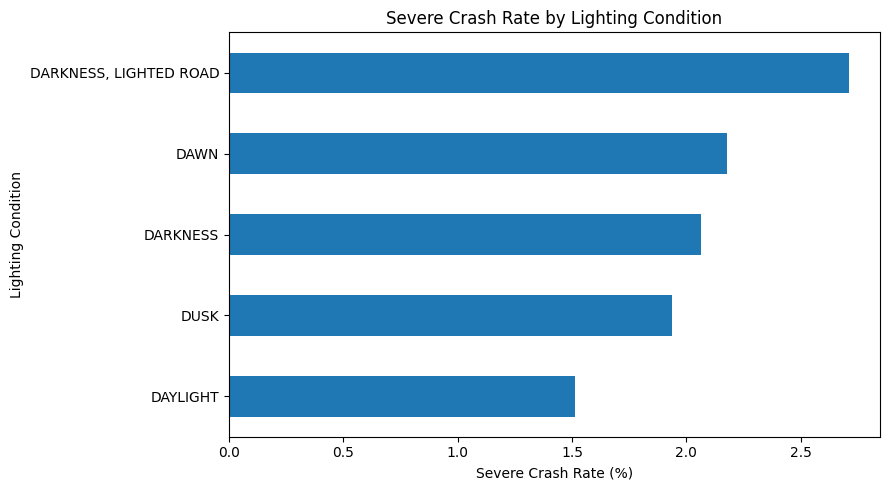

In [87]:
import matplotlib.pyplot as plt

lighting_plot = df_clean[df_clean["LIGHTING_CONDITION"] != "UNKNOWN"].groupby("LIGHTING_CONDITION")["SEVERE_CRASH"].mean().mul(100).sort_values()

lighting_plot.plot(kind="barh", figsize=(9, 5))
plt.xlabel("Severe Crash Rate (%)")
plt.ylabel("Lighting Condition")
plt.title("Severe Crash Rate by Lighting Condition")
plt.tight_layout()
plt.show()

# groupby("LIGHTING_CONDITION") groups the crashes by lighting condition.
# groupby("LIGHTING_CONDITION"), crash kayıtlarını lighting condition'a göre gruplandırır.

# ["SEVERE_CRASH"].mean() calculates the proportion of severe crashes because SEVERE_CRASH contains only 0 and 1.
# ["SEVERE_CRASH"].mean(), SEVERE_CRASH yalnızca 0 ve 1 içerdiği için severe crash oranını hesaplar.

# .mul(100) converts that proportion into a percentage.
# .mul(100), bu oranı yüzdeye çevirir.

# .sort_values() sorts the categories so the horizontal chart is easier to read.
# .sort_values(), horizontal grafiğin daha kolay okunabilmesi için kategorileri sıralar.

# plot(kind="barh") creates a horizontal bar chart, which works well because the lighting-category names are relatively long.
# plot(kind="barh"), lighting kategori isimleri nispeten uzun olduğu için uygun olan yatay bir bar chart oluşturur.

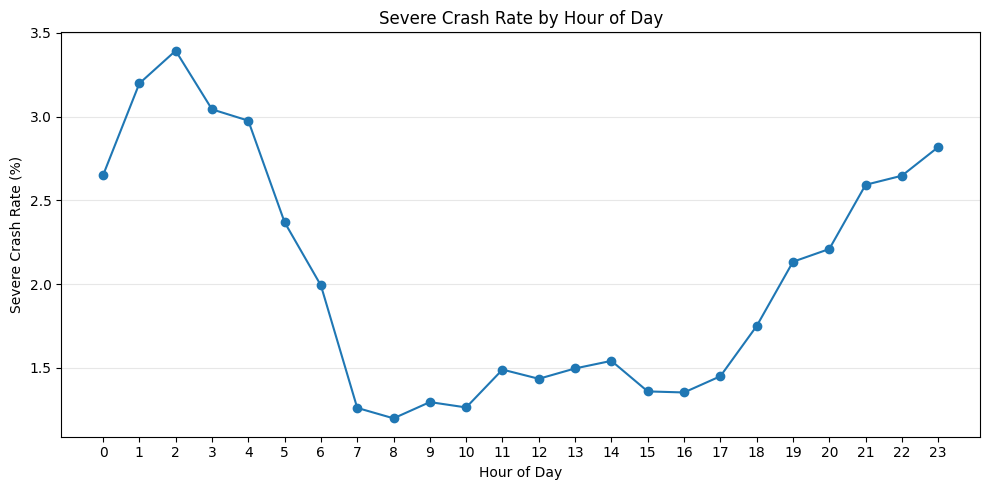

In [88]:
hourly_plot = df_clean.groupby("CRASH_HOUR")["SEVERE_CRASH"].mean().mul(100)

plt.figure(figsize=(10, 5))
plt.plot(hourly_plot.index, hourly_plot.values, marker="o")
plt.xlabel("Hour of Day")
plt.ylabel("Severe Crash Rate (%)")
plt.title("Severe Crash Rate by Hour of Day")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# groupby("CRASH_HOUR") groups crashes into the 24 hours of the day.
# groupby("CRASH_HOUR"), crash kayıtlarını günün 24 saatine göre gruplandırır.

# .mean().mul(100) calculates the severe-crash percentage for each hour.
# .mean().mul(100), her saat için severe-crash yüzdesini hesaplar.

# plt.plot() creates a line chart, which is more appropriate than separate bars here because hour is an ordered time variable.
# plt.plot(), burada hour sıralı bir zaman değişkeni olduğu için ayrı bar'lardan daha uygun olan bir line chart oluşturur.

# marker="o" places a visible point at every hour.
# marker="o", her saatin üzerine görünür bir nokta yerleştirir.

# plt.xticks(range(24)) displays every hour from 0 through 23 on the x-axis.
# plt.xticks(range(24)), x-axis üzerinde 0'dan 23'e kadar bütün saatleri gösterir.

# plt.grid(axis="y", alpha=0.3) adds subtle horizontal reference lines so the percentages are easier to compare.
# plt.grid(axis="y", alpha=0.3), yüzdelerin karşılaştırılmasını kolaylaştırmak için hafif yatay referans çizgileri ekler.

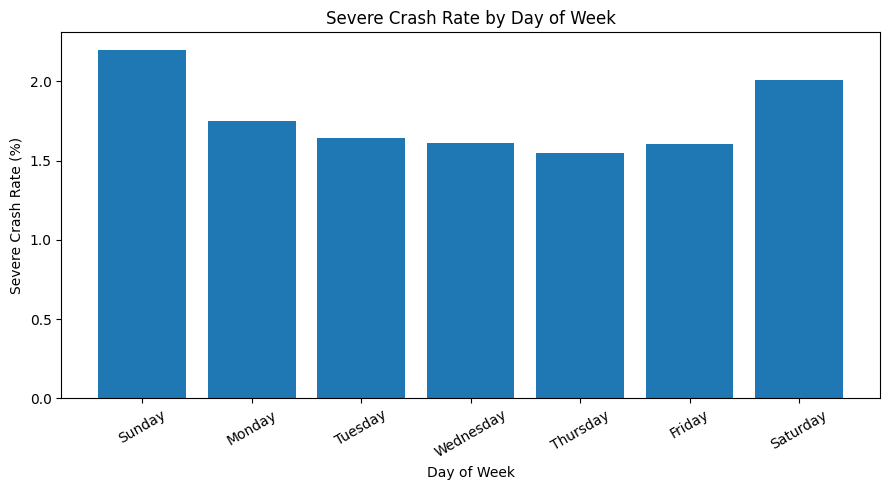

In [89]:
day_labels = {1: "Sunday", 2: "Monday", 3: "Tuesday", 4: "Wednesday", 5: "Thursday", 6: "Friday", 7: "Saturday"}

day_plot = df_clean.groupby("CRASH_DAY_OF_WEEK")["SEVERE_CRASH"].mean().mul(100).reindex(range(1, 8))

plt.figure(figsize=(9, 5))
plt.bar([day_labels[i] for i in day_plot.index], day_plot.values)
plt.xlabel("Day of Week")
plt.ylabel("Severe Crash Rate (%)")
plt.title("Severe Crash Rate by Day of Week")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# day_labels converts the dataset's numeric day codes into readable day names.
# day_labels, veri setindeki sayısal gün kodlarını okunabilir gün isimlerine dönüştürür.

# For this dataset, 1 represents Sunday and 7 represents Saturday.
# Bu veri setinde 1 Sunday'i, 7 ise Saturday'i temsil ediyor.

# groupby("CRASH_DAY_OF_WEEK") groups all crashes according to the day of the week.
# groupby("CRASH_DAY_OF_WEEK"), tüm crash kayıtlarını haftanın gününe göre gruplandırır.

# .mean().mul(100) calculates the severe-crash percentage for each day.
# .mean().mul(100), her gün için severe-crash yüzdesini hesaplar.

# .reindex(range(1, 8)) keeps the days in their natural Sunday-to-Saturday order instead of sorting them by crash rate.
# .reindex(range(1, 8)), günleri crash oranına göre sıralamak yerine doğal Sunday–Saturday sırasında tutar.

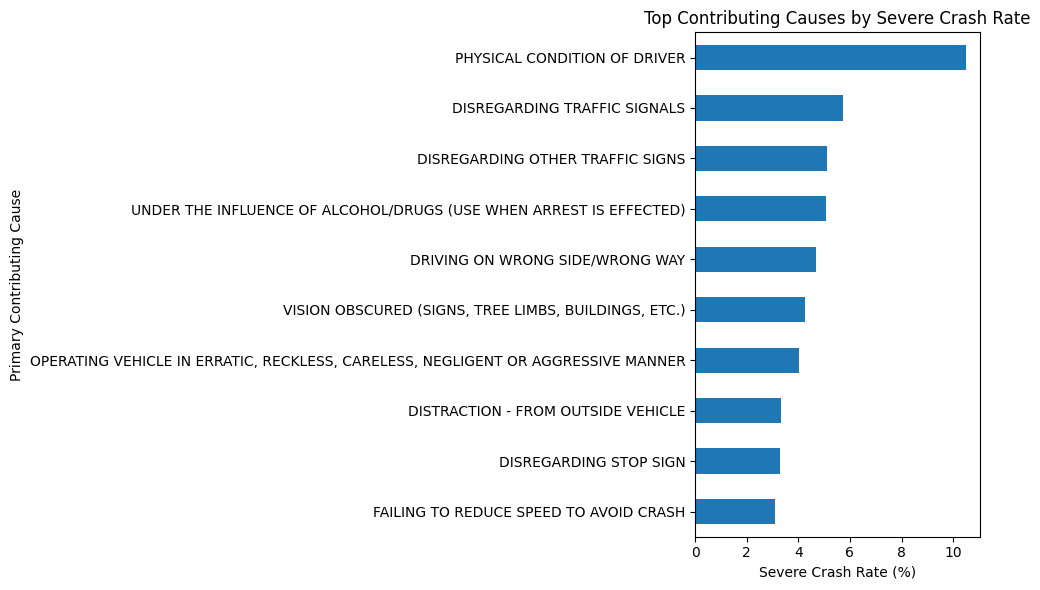

In [90]:
cause_plot = (
    df_clean[
        ~df_clean["PRIM_CONTRIBUTORY_CAUSE"].isin(
            ["UNABLE TO DETERMINE", "NOT APPLICABLE"]
        )
    ]
    .groupby("PRIM_CONTRIBUTORY_CAUSE")["SEVERE_CRASH"]
    .agg(["count", "mean"])
)

cause_plot = cause_plot[cause_plot["count"] >= 1000]
cause_plot["severe_rate"] = cause_plot["mean"] * 100
cause_plot = cause_plot.nlargest(10, "severe_rate").sort_values("severe_rate")

cause_plot["severe_rate"].plot(kind="barh", figsize=(10, 6))
plt.xlabel("Severe Crash Rate (%)")
plt.ylabel("Primary Contributing Cause")
plt.title("Top Contributing Causes by Severe Crash Rate")
plt.tight_layout()
plt.show()

# .agg(["count", "mean"]) calculates both the number of crashes and the severe-crash proportion for every cause.
# .agg(["count", "mean"]), her cause için hem toplam crash sayısını hem de severe-crash oranını hesaplar.

# cause_plot["count"] >= 1000 keeps only categories with at least 1,000 observations.
# cause_plot["count"] >= 1000, yalnızca en az 1.000 gözleme sahip kategorileri tutar.

# .nlargest(10, "severe_rate") selects the ten categories with the highest observed severe-crash rates.
# .nlargest(10, "severe_rate"), gözlemlenen severe-crash oranı en yüksek 10 kategoriyi seçer.

## Key Findings

- Severe crashes represented approximately **1.76%** of the 547,843 crashes analyzed.

- Crash severity varied by lighting condition. Crashes recorded under **darkness with a lighted road** had a severe-crash rate of approximately **2.71%**, compared with **1.51%** during daylight.

- Severe-crash rates were highest during late-night and early-morning hours. The highest observed rate occurred at **2:00 AM (3.39%)**, while most daytime hours had substantially lower rates.

- Weekend crashes had higher severe-crash rates than most weekdays. **Sunday had the highest rate at approximately 2.20%**, followed by **Saturday at 2.01%**.

- Among contributing-cause categories with substantial numbers of observations, **physical condition of the driver** had the highest severe-crash rate at approximately **10.51%**. Other notable categories included disregarding traffic signals, alcohol/drug influence, wrong-way driving, and erratic or reckless driving.

- Statistical testing found significant associations between crash severity and both **lighting condition** and **primary contributing cause** (p < 0.001). However, the effect sizes were relatively weak, with Cramér's V values of **0.046** and **0.117**, respectively.

- These findings describe statistical associations in the observed crash data and should **not be interpreted as evidence of causation**.

## Recommendations

- Traffic-safety efforts could place additional emphasis on **late-night and early-morning periods**, when severe-crash rates were highest in the analyzed data.

- The higher severe-crash rates observed under **darkness and darkness with lighted roads** suggest that nighttime driving conditions should receive particular attention in safety planning.

- Prevention efforts could prioritize high-risk driver behaviors and conditions associated with elevated severe-crash rates, including **disregarding traffic signals, impaired driving, wrong-way driving, and erratic or reckless driving**.

- Weekend patterns, particularly the higher severe-crash rate observed on **Sunday and Saturday**, may help inform the timing of enforcement, education, and other traffic-safety initiatives.

- These recommendations should be interpreted alongside other traffic-safety evidence because the analysis identifies **associations rather than causal effects**.

## Limitations

- The analysis is based on reported Chicago traffic crashes from **2021 through 2025**, so the findings may not generalize to other locations or time periods.

- Some variables contain categories such as **UNKNOWN**, **UNABLE TO DETERMINE**, and **NOT APPLICABLE**, which limit the interpretation of certain crash characteristics and contributing factors.

- A small proportion of records had missing injury information and were excluded from the final analytical dataset.

- Contributing causes are based on recorded crash information and may not capture every factor involved in an incident.

- Severe crashes were relatively uncommon in the dataset, representing approximately **1.76%** of analyzed crashes.

- The statistical tests identify associations between variables, but they do not establish that any analyzed factor caused a severe crash.

## Conclusion

This project analyzed 547,843 reported traffic crashes in Chicago from 2021 through 2025 to identify patterns associated with severe crash outcomes. Severe crashes accounted for approximately 1.76% of the analyzed records.

The analysis showed that severe-crash rates varied across lighting conditions, time of day, day of week, and reported contributing causes. Late-night and early-morning hours showed particularly elevated severe-crash rates, while several driver-related contributing causes were associated with substantially higher rates of severe outcomes.

Statistical testing also found significant associations between crash severity and both lighting condition and primary contributing cause. However, the relatively weak effect sizes and the observational nature of the data mean that these relationships should not be interpreted as causal.

Overall, the project demonstrates how data cleaning, exploratory data analysis, SQL, visualization, and statistical testing can be combined to transform a large real-world dataset into meaningful traffic-safety insights.

**Türkçe Açıklama:**

Bu projede, severe crash sonuçlarıyla ilişkili örüntüleri belirlemek amacıyla 2021–2025 yılları arasında Chicago'da raporlanan 547.843 trafik kazası analiz edildi. Severe crash'ler analiz edilen kayıtların yaklaşık %1,76'sını oluşturdu.

Analiz, severe crash oranlarının aydınlatma koşullarına, günün saatine, haftanın gününe ve raporlanan contributing cause kategorilerine göre değiştiğini gösterdi. Özellikle gece geç saatler ve sabahın erken saatlerinde severe crash oranları daha yüksek görülürken, sürücüyle ilişkili bazı contributing cause kategorileri de daha yüksek severe crash oranlarıyla ilişkiliydi.

İstatistiksel testler ayrıca crash severity ile hem lighting condition hem de primary contributing cause arasında anlamlı ilişkiler bulunduğunu gösterdi. Ancak effect size değerlerinin nispeten düşük olması ve verinin gözlemsel yapısı nedeniyle bu ilişkiler nedensellik olarak yorumlanmamalıdır.

Genel olarak bu proje; data cleaning, exploratory data analysis, SQL, visualization ve statistical testing yöntemlerinin büyük ve gerçek bir veri setini anlamlı trafik güvenliği bulgularına dönüştürmek için nasıl birlikte kullanılabileceğini göstermektedir.